# Student: Tairbek Akhayev
# Matricola: 551094


# 1.Understanding the dataset:

## 1.1 Feature description

### Setup


In [1]:
import sys

# Scikit-Learn
import sklearn

# Common imports
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns

# To plot
import matplotlib as mpl
import matplotlib.pyplot as plt

### Get the data

In [2]:
df = pd.read_csv('/Users/tairakhayev/Desktop/Data Mining/project/dataset_churn.csv')


### Data structure

In [3]:
df.shape

(3749, 17)

In [4]:
df.head()

,Unnamed: 0,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,0,08729464-bde6-43bc-8f63-a357096feab1,56.0,Male,13,DSL,Yes,No,One year,Mailed check,71.88,931.49,No,No,Yes,No,No
1,1,af95bc95-baf4-4318-a21d-70d2ea3148b7,69.0,Male,13,DSL,No,Yes,Two year,Mailed check,110.99,1448.46,Yes,Yes,No,No,No
2,2,1fe7eee6-2227-4400-9998-4d993f4a60fd,46.0,Male,60,Fiber optic,No,Yes,Month-to-month,Mailed check,116.74,6997.73,Yes,Yes,No,No,No
3,3,f736fe7b-1b44-4acd-84c2-21c4aef648be,32.0,Female,57,Fiber optic,Yes,Yes,Month-to-month,Bank transfer,78.16,4452.13,No,Yes,No,Yes,No
4,4,4b40d12d-7633-4309-96b8-aee675ea20ae,60.0,Male,52,Fiber optic,Yes,Yes,Two year,Electronic check,30.33,1569.73,Yes,No,Yes,Yes,No


### Statistical information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3749 entries, 0 to 3748
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        3749 non-null   int64  
 1   CustomerID        3749 non-null   object 
 2   Age               3562 non-null   float64
 3   Gender            3749 non-null   object 
 4   Tenure            3749 non-null   int64  
 5   Service_Internet  3028 non-null   object 
 6   Service_Phone     3749 non-null   object 
 7   Service_TV        3749 non-null   object 
 8   Contract          3749 non-null   object 
 9   PaymentMethod     3562 non-null   object 
 10  MonthlyCharges    3749 non-null   float64
 11  TotalCharges      3749 non-null   float64
 12  StreamingMovies   3749 non-null   object 
 13  StreamingMusic    3749 non-null   object 
 14  OnlineSecurity    3749 non-null   object 
 15  TechSupport       3749 non-null   object 
 16  Churn             3749 non-null   object 


In [6]:
df.dtypes

Unnamed: 0            int64
CustomerID           object
Age                 float64
Gender               object
Tenure                int64
Service_Internet     object
Service_Phone        object
Service_TV           object
Contract             object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
StreamingMovies      object
StreamingMusic       object
OnlineSecurity       object
TechSupport          object
Churn                object
dtype: object

In [7]:
df.nunique()

Unnamed: 0          3749
CustomerID          3749
Age                   52
Gender                 2
Tenure                71
Service_Internet       2
Service_Phone          2
Service_TV             2
Contract               3
PaymentMethod          4
MonthlyCharges      3118
TotalCharges        3735
StreamingMovies        2
StreamingMusic         2
OnlineSecurity         2
TechSupport            2
Churn                  2
dtype: int64

In [8]:
df.describe()

,Unnamed: 0,Age,Tenure,MonthlyCharges,TotalCharges
count,3749.000000,3562.000000,3749.000000,3749.000000,3749.000000
mean,1874.000000,43.655531,36.264070,75.844318,2718.968266
std,1082.387408,14.914474,20.505528,73.062971,3211.879149
min,0.000000,18.000000,1.000000,20.000000,13.190000
25%,937.000000,31.000000,19.000000,44.570000,1076.240000
50%,1874.000000,44.000000,36.000000,69.590000,2132.260000
75%,2811.000000,56.000000,54.000000,95.540000,3619.710000
max,3748.000000,69.000000,71.000000,1179.300000,79951.800000


In [9]:
df.columns.values

array(['Unnamed: 0', 'CustomerID', 'Age', 'Gender', 'Tenure',
       'Service_Internet', 'Service_Phone', 'Service_TV', 'Contract',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'StreamingMovies', 'StreamingMusic', 'OnlineSecurity',
       'TechSupport', 'Churn'], dtype=object)

### 1.2. Data visualization

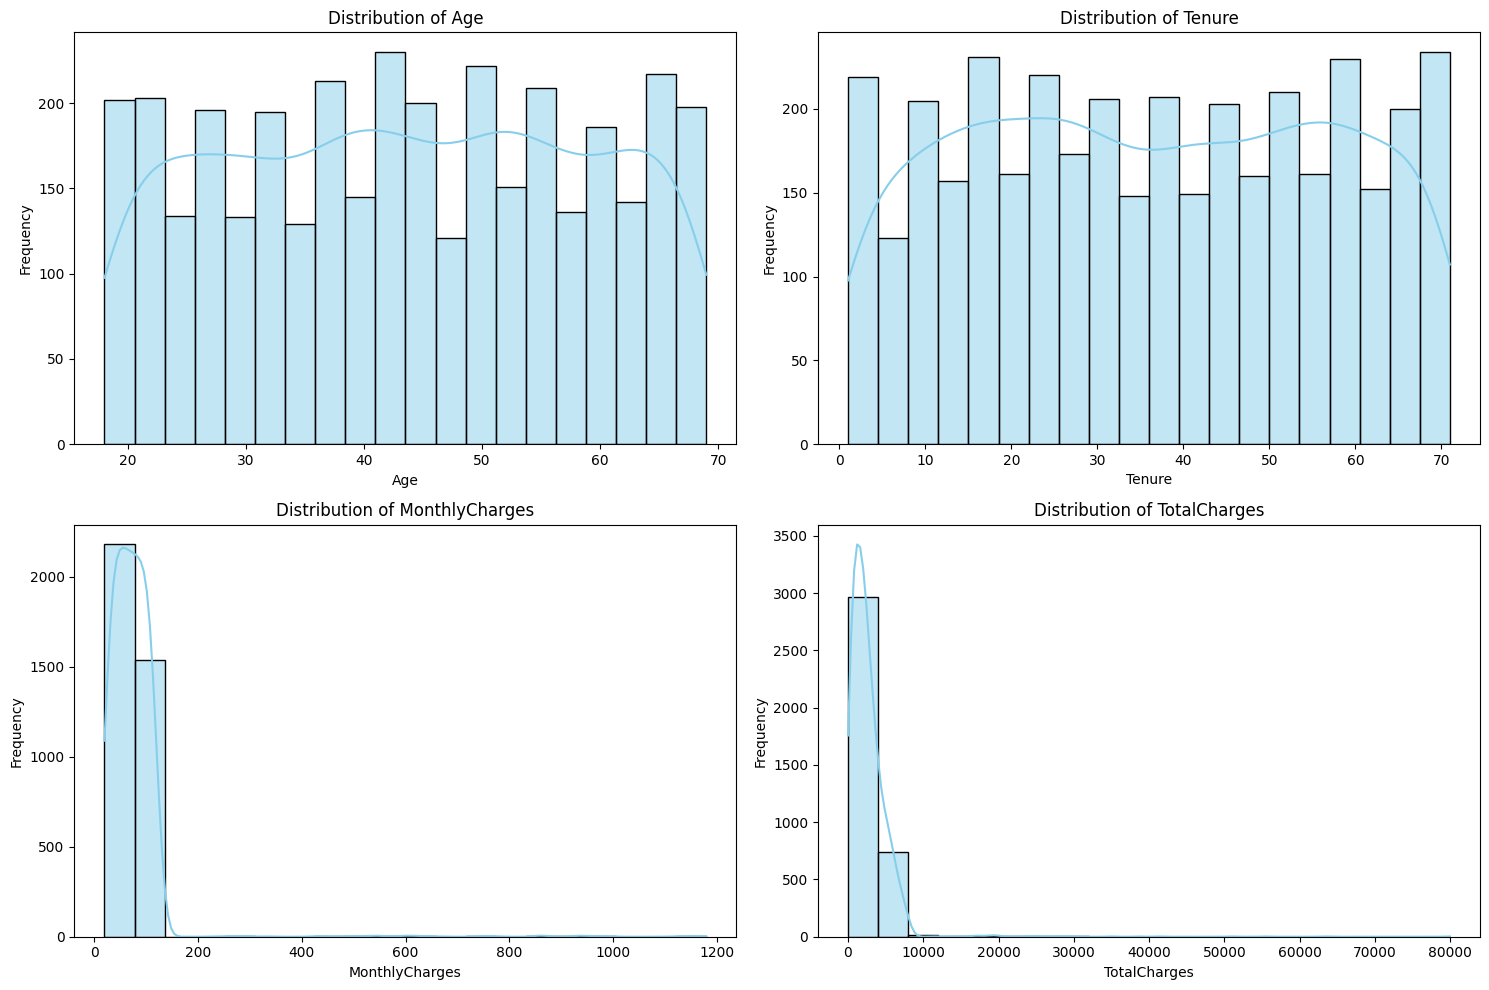

In [10]:
#histograms

# Select numerical features
numerical_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

# Calculate the number of rows and columns for the subplot grid
num_features = len(numerical_features)
num_cols = int(np.ceil(np.sqrt(num_features)))
num_rows = int(np.ceil(num_features / num_cols))

# Create a figure and axis objects for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Plot histograms for each numerical feature
for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], kde=True, bins=20, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout
plt.tight_layout()
plt.show()


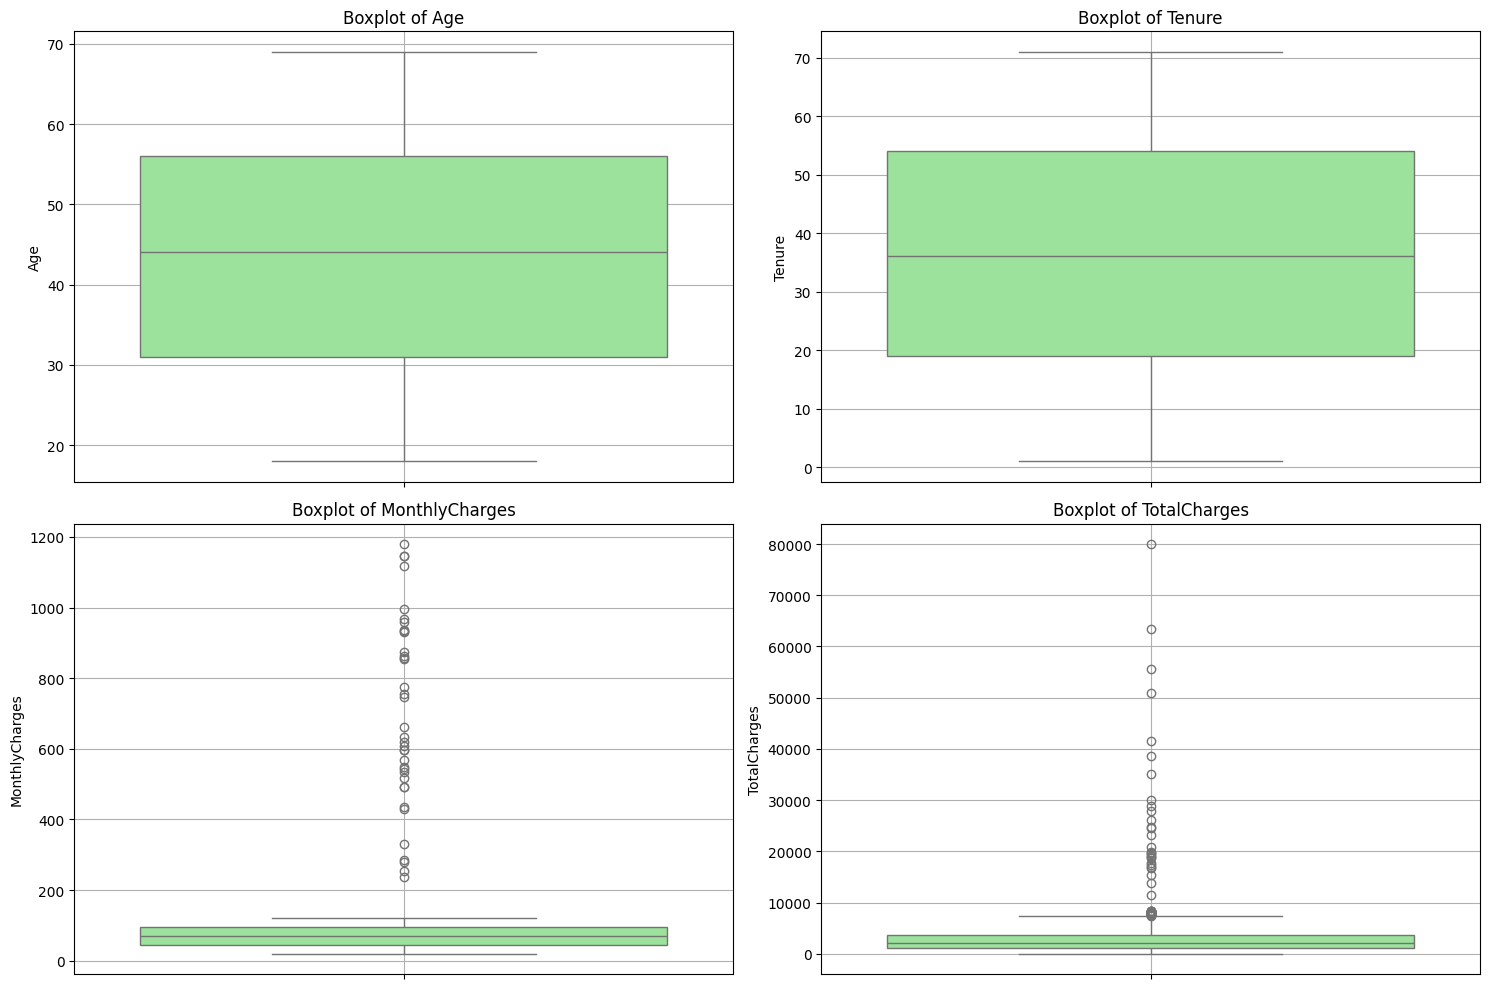

In [11]:
# Calculate the number of rows and columns for the subplot grid
num_features = len(numerical_features)
num_cols = int(np.ceil(np.sqrt(num_features)))
num_rows = int(np.ceil(num_features / num_cols))

# Create a figure and axis objects for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Plot box plots for each numerical feature
for i, feature in enumerate(numerical_features):
    sns.boxplot(y=df[feature], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_ylabel(feature)
    axes[i].grid(True)

# Hide unused subplots
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout
plt.tight_layout()
plt.show()


### 1.3. Relationship analysis

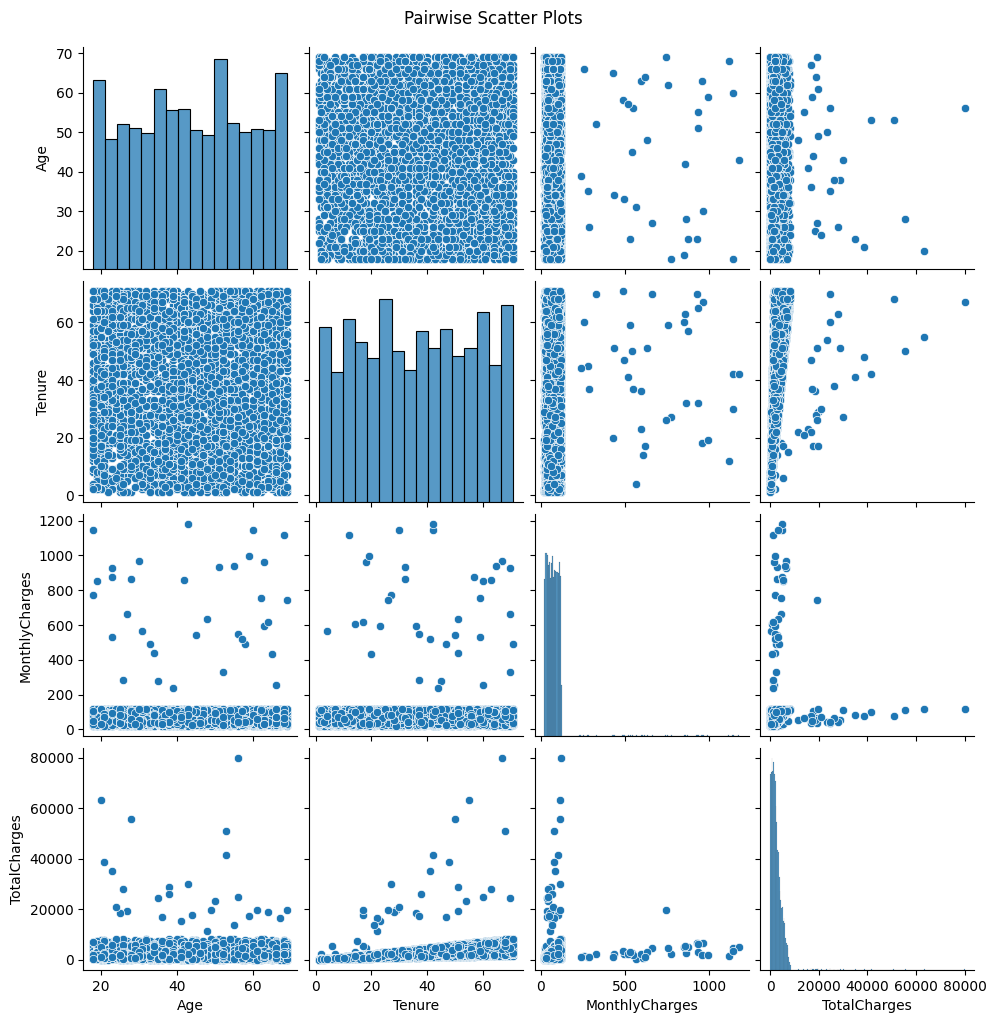

In [12]:
# Select a subset of features for scatter plot analysis
scatter_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

# Plot scatter plots for selected features
sns.pairplot(df[scatter_features])
plt.suptitle('Pairwise Scatter Plots', y=1.02)
plt.show()

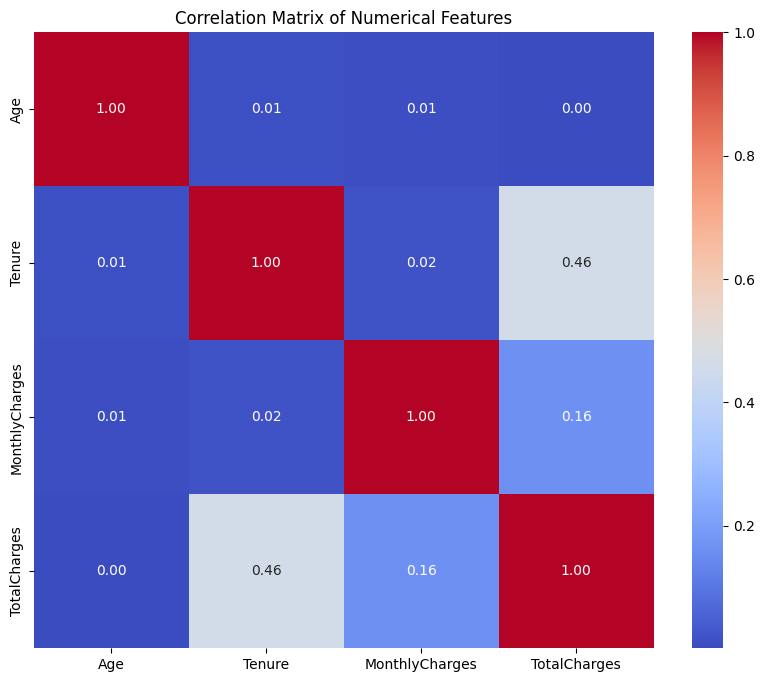

In [13]:
# Calculate the correlation matrix
correlation_matrix = df[numerical_features].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 2. Data Preprocessing

### 2.1. Handling missing values

In [14]:
df.isnull().sum()

Unnamed: 0            0
CustomerID            0
Age                 187
Gender                0
Tenure                0
Service_Internet    721
Service_Phone         0
Service_TV            0
Contract              0
PaymentMethod       187
MonthlyCharges        0
TotalCharges          0
StreamingMovies       0
StreamingMusic        0
OnlineSecurity        0
TechSupport           0
Churn                 0
dtype: int64

In [15]:
df = df.drop(columns=["Unnamed: 0"])

In [16]:
from sklearn.impute import SimpleImputer
# Age: Impute missing values using mean imputation
age_imputer = SimpleImputer(strategy='mean')  
df['Age'] = age_imputer.fit_transform(df[['Age']])

In [17]:
df['Service_Internet'].nunique()

2

In [18]:
# Service_Internet: Replace missing values with a new category
df['Service_Internet'].fillna('Unknown', inplace=True)

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/4074289733.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Service_Internet'].fillna('Unknown', inplace=True)


In [19]:
# PaymentMethod: Impute missing values using mode imputation
payment_imputer = SimpleImputer(strategy='most_frequent')
# Ensure that the input data is a 2D array
payment_data = df[['PaymentMethod']]
payment_data_imputed = payment_imputer.fit_transform(payment_data)
# Assign the imputed values back to the DataFrame
df['PaymentMethod'] = payment_data_imputed.reshape(-1)  # Reshape to 1D array

In [20]:
# Verify missing value handling
missing_values_after = df.isnull().sum()
print("Missing Values After Handling:")
print(missing_values_after)

Missing Values After Handling:
CustomerID          0
Age                 0
Gender              0
Tenure              0
Service_Internet    0
Service_Phone       0
Service_TV          0
Contract            0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
StreamingMovies     0
StreamingMusic      0
OnlineSecurity      0
TechSupport         0
Churn               0
dtype: int64


### 2.2. Treating outliers

#### Boxplots and Histograms

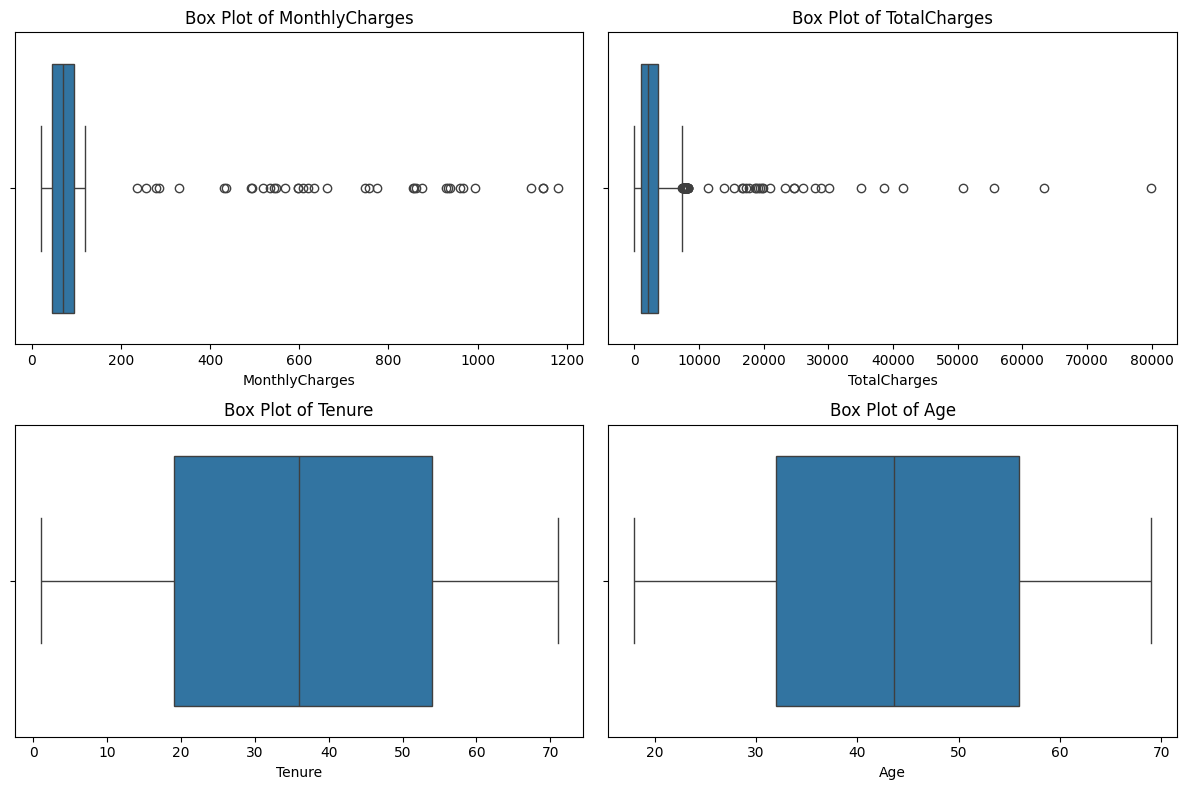

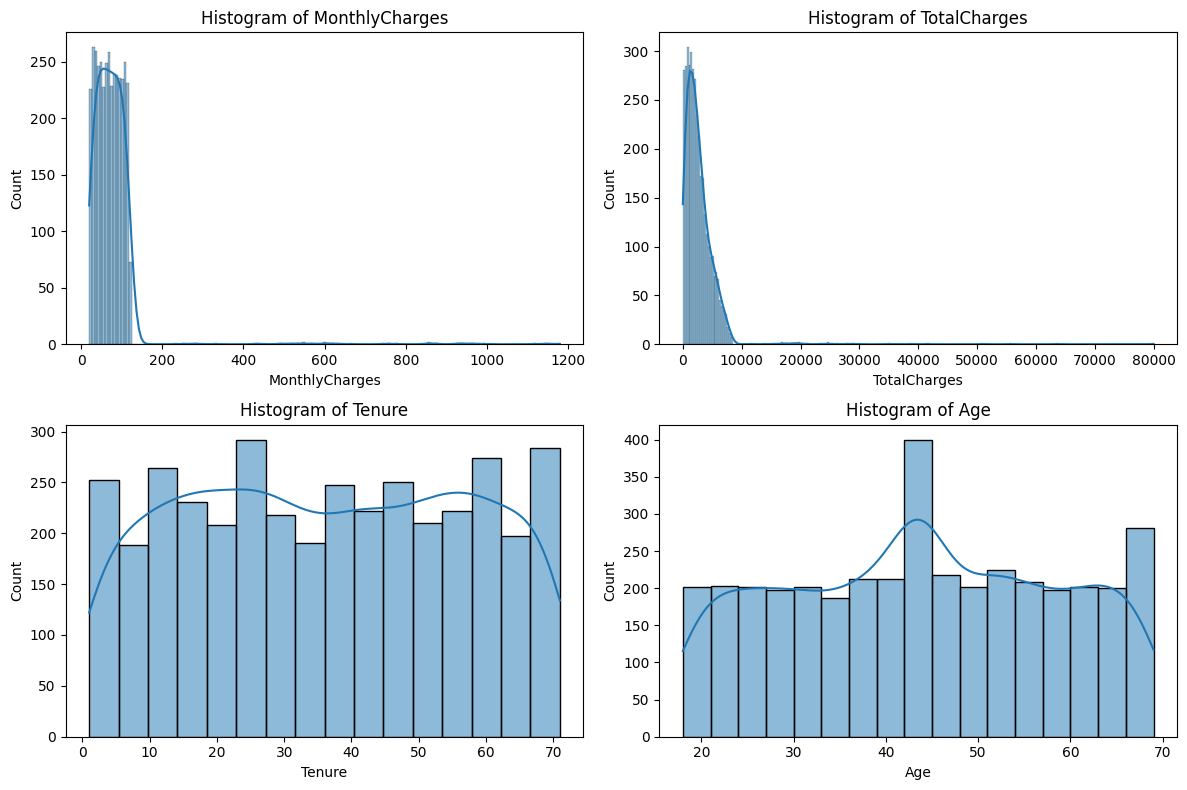

In [21]:
# Define numerical features
numerical_features = ['MonthlyCharges', 'TotalCharges', 'Tenure', 'Age']

# Create box plots for numerical features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# Create histograms for numerical features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.cluster import KMeans

# Select numerical features for clustering
numerical_features = ['MonthlyCharges', 'TotalCharges']
X = df[numerical_features]

# Fit K-Means clustering
kmeans = KMeans(n_clusters=2)  # Assuming there are outliers in one cluster
kmeans.fit(X)

# Get cluster labels and centroids
cluster_labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Calculate distance from each point to its cluster centroid
distances = []
for i in range(len(X)):
    cluster_idx = cluster_labels[i]
    centroid = centroids[cluster_idx]
    distance = np.linalg.norm(X.iloc[i] - centroid)
    distances.append(distance)

# Identify outliers as points with distances above a certain threshold
outlier_threshold = np.percentile(distances, 95)  # Adjust percentile as needed
outliers = df[distances > outlier_threshold]

print("Outliers identified using K-Means Clustering:")
print(outliers)


Outliers identified using K-Means Clustering:
                                CustomerID        Age  Gender  Tenure  \
5     0fece405-89c9-44a4-9ffb-29e55a4bbf55  25.000000  Female      53   
7     b4db2101-be85-4048-8201-659b9f3345a9  56.000000    Male      42   
15    6dee6bf9-191d-44f5-9be0-ea333d0a78a5  41.000000    Male      39   
30    96fc0d97-77b2-4e53-9d7d-e79d0e629b83  43.655531    Male      42   
44    8282b377-1276-4472-ba8e-a352ee13aae0  38.000000    Male      51   
...                                    ...        ...     ...     ...   
3667  8444217d-88d0-4e51-8e18-499adf9c2516  39.000000    Male      69   
3668  24eeefb9-cada-476f-9be8-16998df92e8c  43.655531  Female      33   
3684  24a9e737-92da-40df-9979-76b8a78ff4b2  42.000000    Male      42   
3719  dc883128-9c84-4775-a137-8764be8466c7  59.000000    Male      37   
3733  b5b33b95-c6f9-44c0-850d-f750f996e11a  56.000000    Male      60   

     Service_Internet Service_Phone Service_TV        Contract  \
5         F

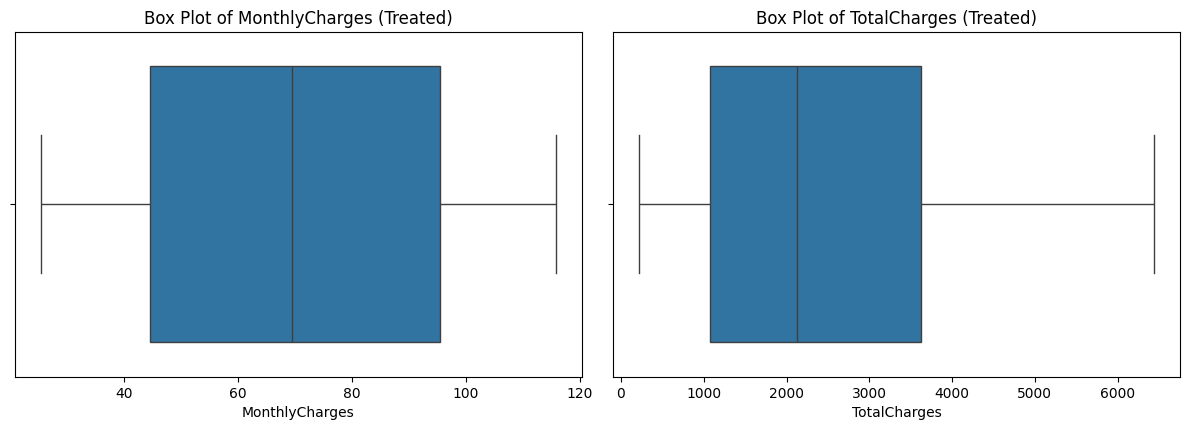

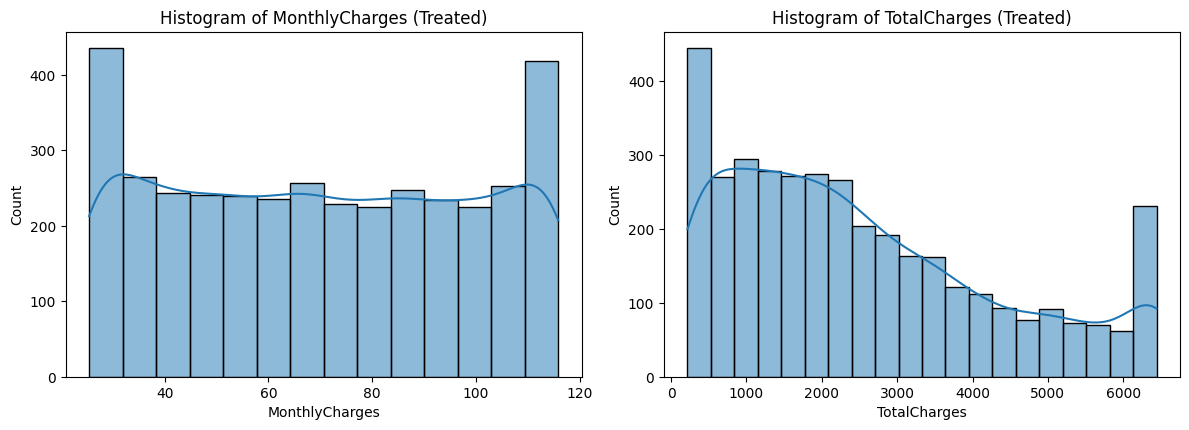

In [23]:
# Treat outliers using clipping directly on the original numerical features
numerical_features = ['MonthlyCharges', 'TotalCharges']
for feature in numerical_features:
    low_threshold = df[feature].quantile(0.05)
    high_threshold = df[feature].quantile(0.95)
    df[feature] = df[feature].clip(lower=low_threshold, upper=high_threshold)

# Visualize updated box plots
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature} (Treated)')
plt.tight_layout()
plt.show()

# Visualize updated histograms
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature} (Treated)')
plt.tight_layout()
plt.show()


### 2.3. Encode categorical variables

In [24]:
# Define the columns to map
columns_to_map = ['OnlineSecurity', 'TechSupport', 'Churn']

# Define the mapping dictionary
mapping_dict = {'No': False, 'Yes': True}

# Map 'No' and 'Yes' to 0 and 1 for the specified columns
df[columns_to_map] = df[columns_to_map].replace(mapping_dict)

# Display the updated DataFrame
df.head()

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/1882531071.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columns_to_map] = df[columns_to_map].replace(mapping_dict)


,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,08729464-bde6-43bc-8f63-a357096feab1,56.0,Male,13,DSL,Yes,No,One year,Mailed check,71.880,931.490,No,No,True,False,False
1,af95bc95-baf4-4318-a21d-70d2ea3148b7,69.0,Male,13,DSL,No,Yes,Two year,Mailed check,110.990,1448.460,Yes,Yes,False,False,False
2,1fe7eee6-2227-4400-9998-4d993f4a60fd,46.0,Male,60,Fiber optic,No,Yes,Month-to-month,Mailed check,115.822,6442.062,Yes,Yes,False,False,False
3,f736fe7b-1b44-4acd-84c2-21c4aef648be,32.0,Female,57,Fiber optic,Yes,Yes,Month-to-month,Bank transfer,78.160,4452.130,No,Yes,False,True,False
4,4b40d12d-7633-4309-96b8-aee675ea20ae,60.0,Male,52,Fiber optic,Yes,Yes,Two year,Electronic check,30.330,1569.730,Yes,No,True,True,False


In [25]:
# Perform one-hot encoding for categorical variables
columns_to_encode = ['Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=columns_to_encode)

df.head()

,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,MonthlyCharges,TotalCharges,StreamingMovies,...,OnlineSecurity,TechSupport,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,08729464-bde6-43bc-8f63-a357096feab1,56.0,Male,13,DSL,Yes,No,71.880,931.490,No,...,True,False,False,False,True,False,False,False,False,True
1,af95bc95-baf4-4318-a21d-70d2ea3148b7,69.0,Male,13,DSL,No,Yes,110.990,1448.460,Yes,...,False,False,False,False,False,True,False,False,False,True
2,1fe7eee6-2227-4400-9998-4d993f4a60fd,46.0,Male,60,Fiber optic,No,Yes,115.822,6442.062,Yes,...,False,False,False,True,False,False,False,False,False,True
3,f736fe7b-1b44-4acd-84c2-21c4aef648be,32.0,Female,57,Fiber optic,Yes,Yes,78.160,4452.130,No,...,False,True,False,True,False,False,True,False,False,False
4,4b40d12d-7633-4309-96b8-aee675ea20ae,60.0,Male,52,Fiber optic,Yes,Yes,30.330,1569.730,Yes,...,True,True,False,False,False,True,False,False,True,False


### 2.4. Feature scaling and normalization

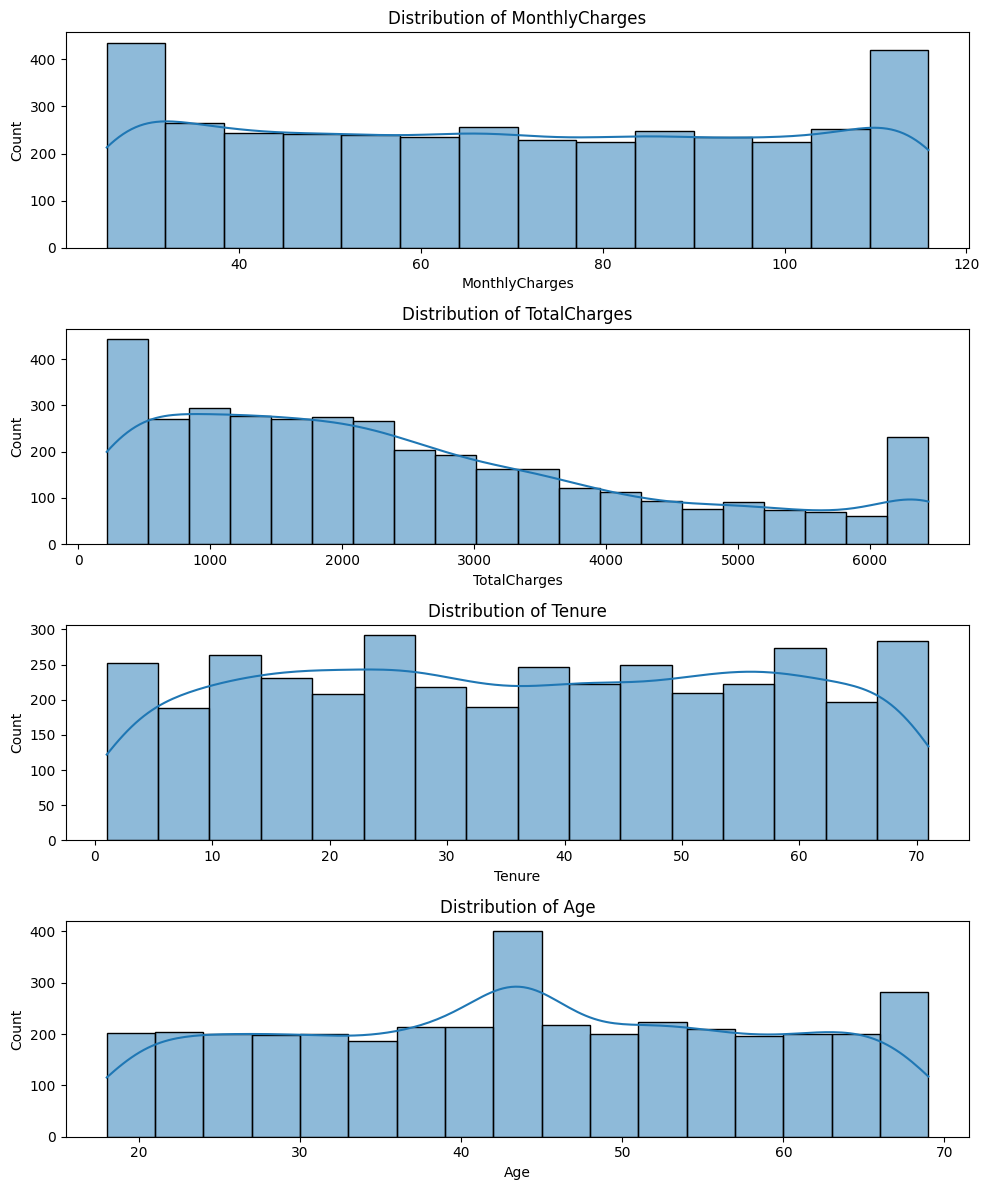

In [26]:
numerical_features = ['MonthlyCharges', 'TotalCharges', 'Tenure', 'Age']

# Set up subplots for each feature
fig, axes = plt.subplots(nrows=len(numerical_features), ncols=1, figsize=(10, 12))

# Plot histograms for each numerical feature
for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Min-Max Scaling
scaler = MinMaxScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Display normalized or scaled dataset
df.head()

,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,MonthlyCharges,TotalCharges,StreamingMovies,...,OnlineSecurity,TechSupport,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,08729464-bde6-43bc-8f63-a357096feab1,0.745098,Male,0.171429,DSL,Yes,No,0.513798,0.114698,No,...,True,False,False,False,True,False,False,False,False,True
1,af95bc95-baf4-4318-a21d-70d2ea3148b7,1.000000,Male,0.171429,DSL,No,Yes,0.946536,0.197752,Yes,...,False,False,False,False,False,True,False,False,False,True
2,1fe7eee6-2227-4400-9998-4d993f4a60fd,0.549020,Male,0.842857,Fiber optic,No,Yes,1.000000,1.000000,Yes,...,False,False,False,True,False,False,False,False,False,True
3,f736fe7b-1b44-4acd-84c2-21c4aef648be,0.274510,Female,0.800000,Fiber optic,Yes,Yes,0.583284,0.680307,No,...,False,True,False,True,False,False,True,False,False,False
4,4b40d12d-7633-4309-96b8-aee675ea20ae,0.823529,Male,0.728571,Fiber optic,Yes,Yes,0.054062,0.217235,Yes,...,True,True,False,False,False,True,False,False,True,False


In [28]:
df.to_csv("cleaned_dataset.csv", index=False)

# 3. Exploratory Data Analysis (EDA)

### 3.1. Investigate the relationship between features and the target variable (Churn)

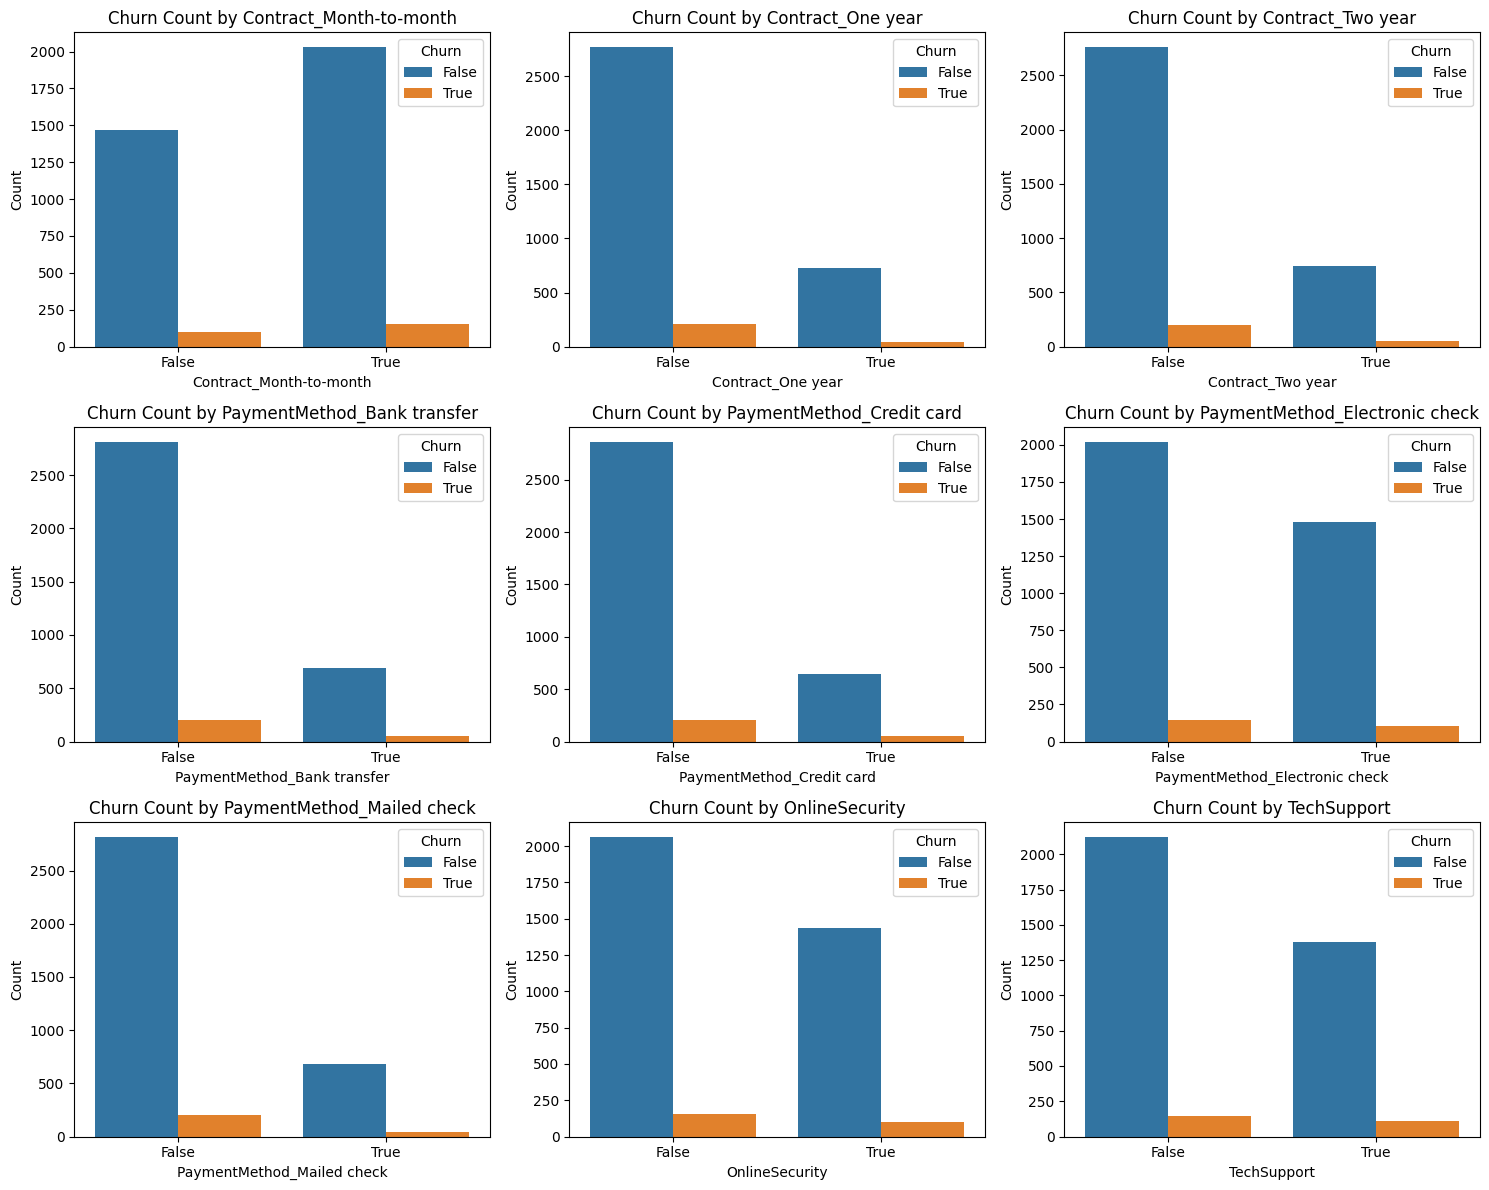

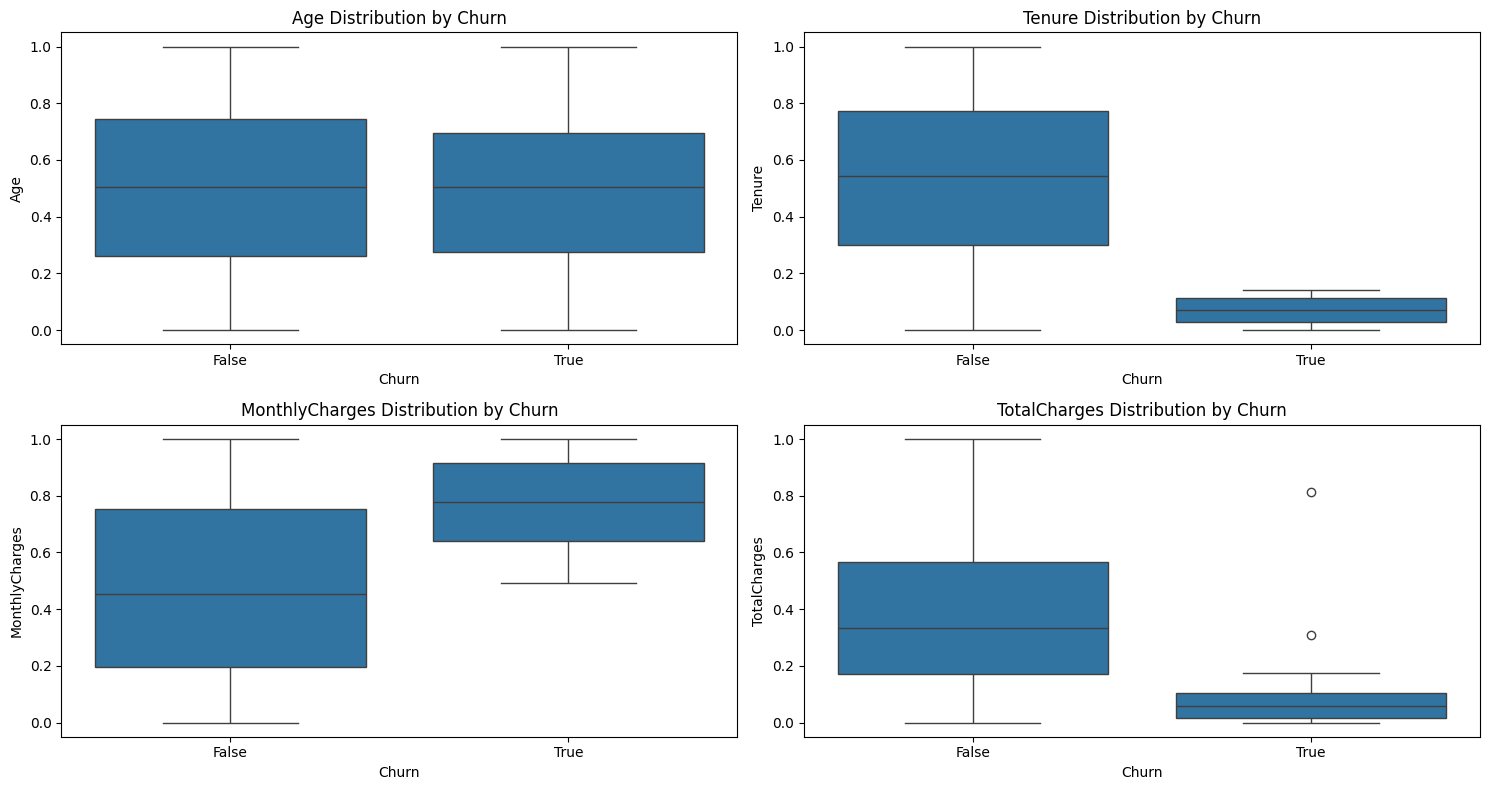

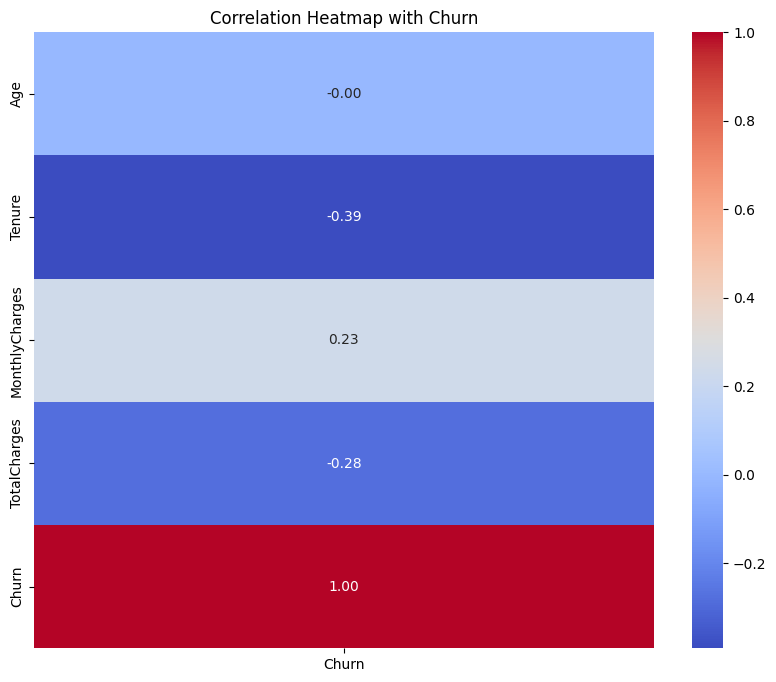

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar charts for categorical features
categorical_features = ['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
                        'PaymentMethod_Bank transfer', 'PaymentMethod_Credit card',
                        'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
                        'OnlineSecurity', 'TechSupport']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=feature, hue='Churn', data=df)
    plt.title(f'Churn Count by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Box plots for numerical features
numerical_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Churn', y=feature, data=df)
    plt.title(f'{feature} Distribution by Churn')
    plt.xlabel('Churn')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# Heatmap of correlation coefficients
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(correlation_matrix[['Churn']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap with Churn')
plt.show()


/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2610216504.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Service_Internet', y='Churn', data=df, estimator=sum, ci=None, order=unique_internet_services)


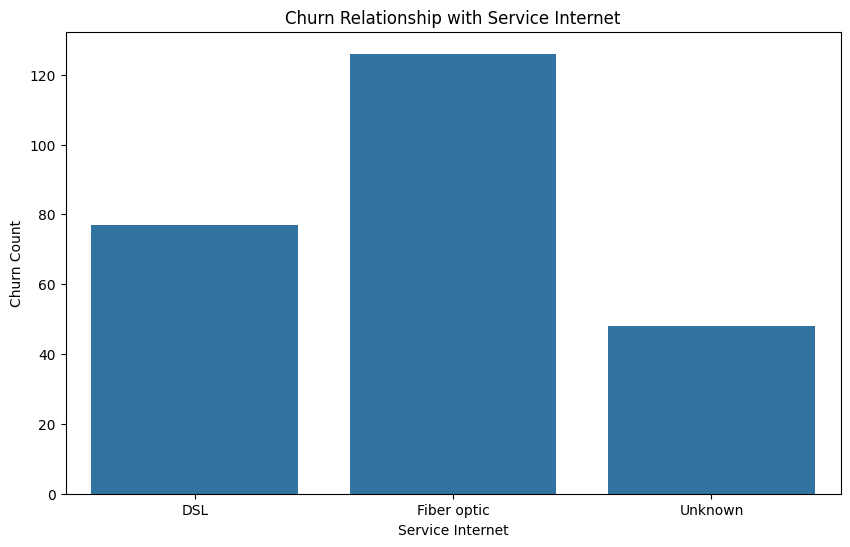

In [30]:
# Get unique values in the 'Service_Internet' column
unique_internet_services = df['Service_Internet'].unique()

# Plot churn relationship for each unique value in 'Service_Internet'
plt.figure(figsize=(10, 6))
sns.barplot(x='Service_Internet', y='Churn', data=df, estimator=sum, ci=None, order=unique_internet_services)
plt.xlabel('Service Internet')
plt.ylabel('Churn Count')
plt.title('Churn Relationship with Service Internet')
plt.show()

In [31]:
unique_values_count = df['Service_Internet'].value_counts()
print(unique_values_count)

Service_Internet
Fiber optic    1908
DSL            1120
Unknown         721
Name: count, dtype: int64


#### Correlation analysis

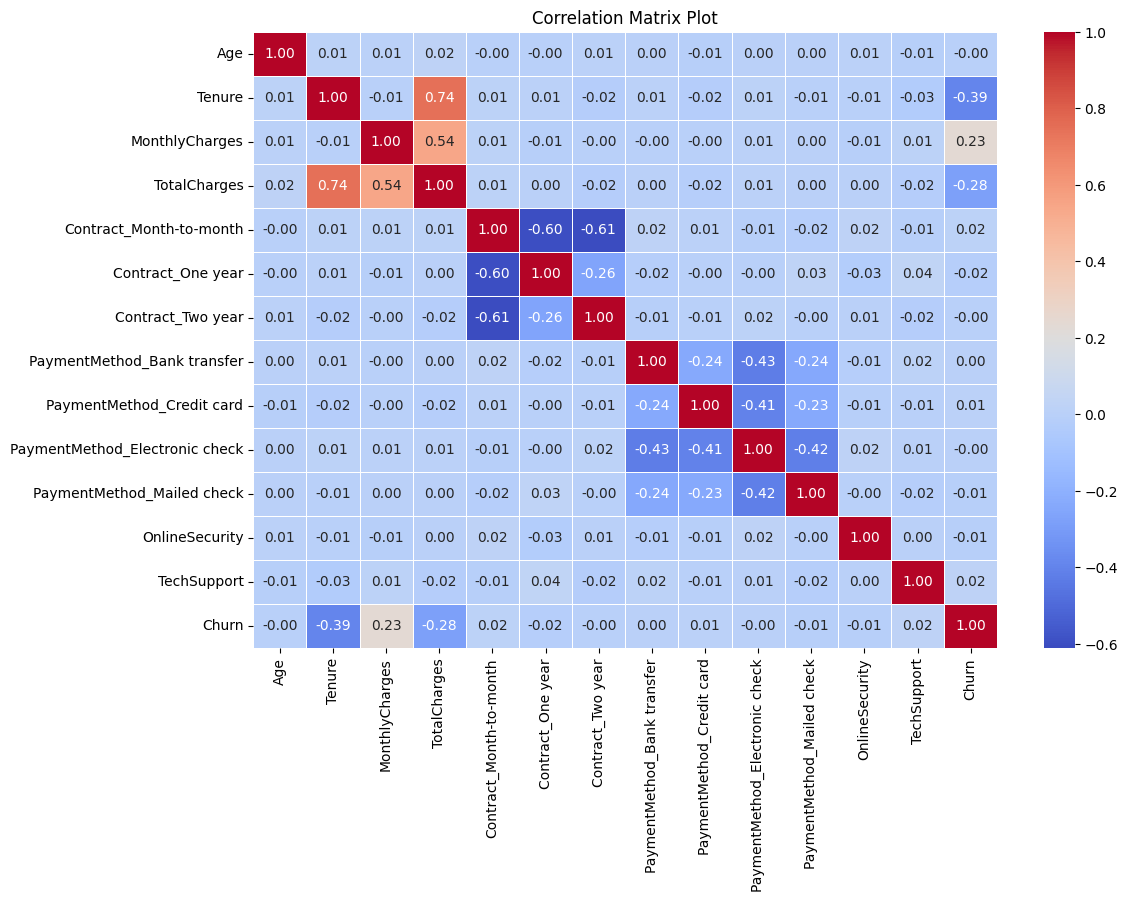

In [32]:
# Select only the specified features and 'Churn' column
selected_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
                     'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
                     'PaymentMethod_Bank transfer', 'PaymentMethod_Credit card',
                     'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
                     'OnlineSecurity', 'TechSupport', 'Churn']
correlation_selected = df[selected_features].corr()

# Plot correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_selected, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Plot')
plt.show()

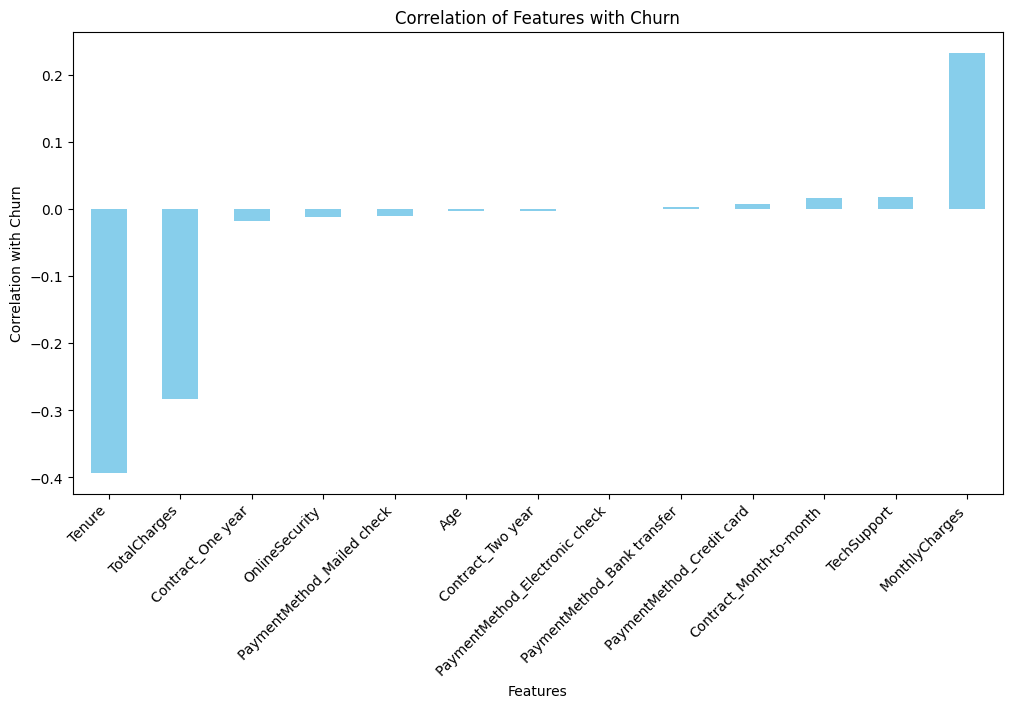

In [33]:
# Define the features
features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
            'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
            'PaymentMethod_Bank transfer', 'PaymentMethod_Credit card',
            'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
            'OnlineSecurity', 'TechSupport', 'Churn']

# Filter the DataFrame to include only the selected features
selected_df = df[features]

# Calculate the correlation matrix
correlation_matrix = selected_df.corr()

# Get the correlation of features with 'Churn'
churn_correlation = correlation_matrix['Churn'].drop('Churn')

# Plot the correlations
plt.figure(figsize=(12, 6))
churn_correlation.sort_values().plot(kind='bar', color='skyblue')
plt.xlabel('Features')
plt.ylabel('Correlation with Churn')
plt.title('Correlation of Features with Churn')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Feature importance

In [34]:
from sklearn.ensemble import RandomForestClassifier
# Feature Importance
# Prepare data for modeling
X = df.drop(columns=['CustomerID', 'Gender', 'Service_Internet', 'Service_Phone', 'Service_TV', 'StreamingMovies', 'StreamingMusic', 'Churn'])
y = df['Churn']

# Train Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance Scores:")
print(feature_importance)


Feature Importance Scores:
MonthlyCharges                    0.390877
Tenure                            0.360458
TotalCharges                      0.204682
Age                               0.023104
TechSupport                       0.003467
OnlineSecurity                    0.003228
PaymentMethod_Electronic check    0.002361
Contract_Month-to-month           0.002291
PaymentMethod_Mailed check        0.002172
Contract_Two year                 0.001966
PaymentMethod_Bank transfer       0.001947
PaymentMethod_Credit card         0.001846
Contract_One year                 0.001601
dtype: float64


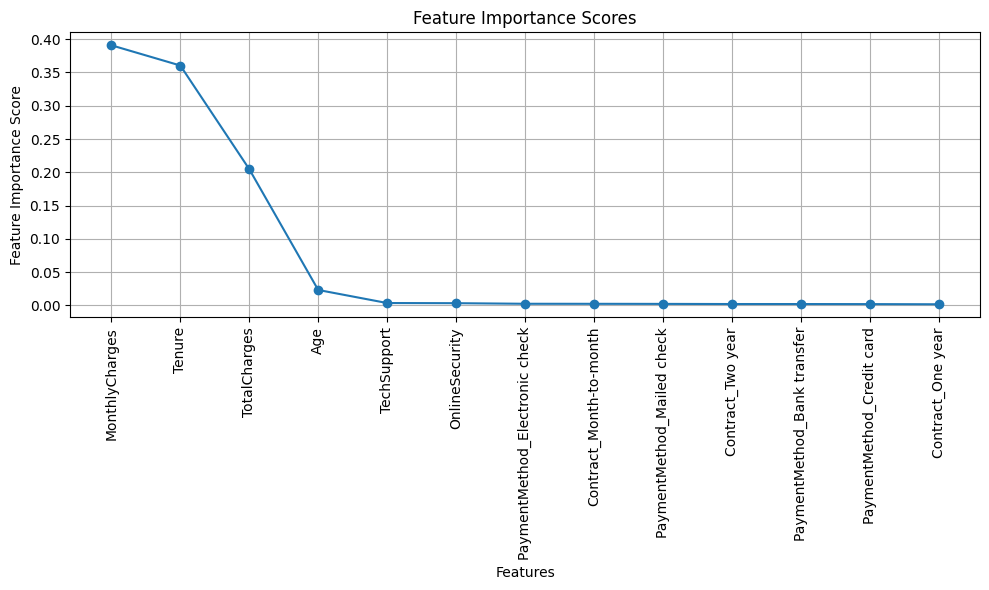

In [35]:
# Plotting Feature Importance Scores with Lines
plt.figure(figsize=(10, 6))
plt.plot(feature_importance.values, marker='o', linestyle='-')
plt.xticks(np.arange(len(feature_importance)), feature_importance.index, rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature Importance Score')
plt.title('Feature Importance Scores')
plt.grid(True)
plt.tight_layout()
plt.show()

### Checking assumptions

#### Does payment methods affect churn?

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2713368261.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_true_counts.index, y=churn_true_counts.values, palette='coolwarm')
/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2713368261.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_false_counts.index, y=churn_false_counts.values, palette='coolwarm')


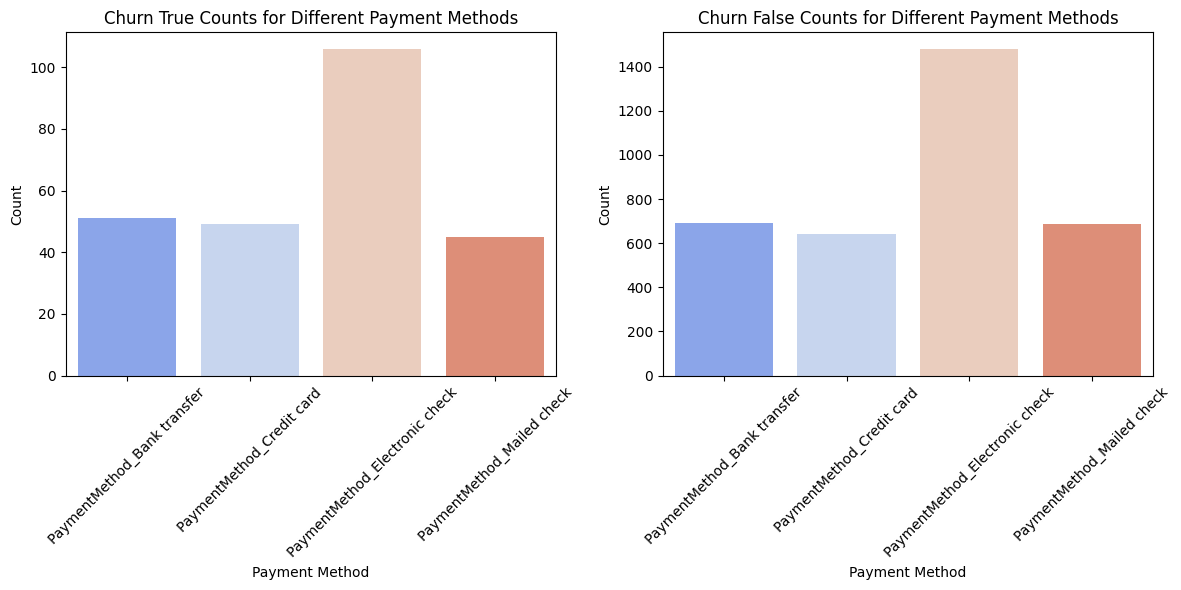

In [36]:
# Filter dataframe for churn True and churn False
df_churn_true = df[df['Churn'] == True]
df_churn_false = df[df['Churn'] == False]

# Calculate churn counts for each payment method for churn True and churn False
churn_true_counts = df_churn_true.filter(like='PaymentMethod').sum()
churn_false_counts = df_churn_false.filter(like='PaymentMethod').sum()

# Plot bar plots for churn True and churn False
plt.figure(figsize=(12, 6))

# Bar plot for churn True
plt.subplot(1, 2, 1)
sns.barplot(x=churn_true_counts.index, y=churn_true_counts.values, palette='coolwarm')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Churn True Counts for Different Payment Methods')
plt.xticks(rotation=45)

# Bar plot for churn False
plt.subplot(1, 2, 2)
sns.barplot(x=churn_false_counts.index, y=churn_false_counts.values, palette='coolwarm')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Churn False Counts for Different Payment Methods')
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()


#### Does contract time affect churn?

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/3325884322.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_true_counts.index, y=churn_true_counts.values, palette='coolwarm')
/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/3325884322.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_false_counts.index, y=churn_false_counts.values, palette='coolwarm')


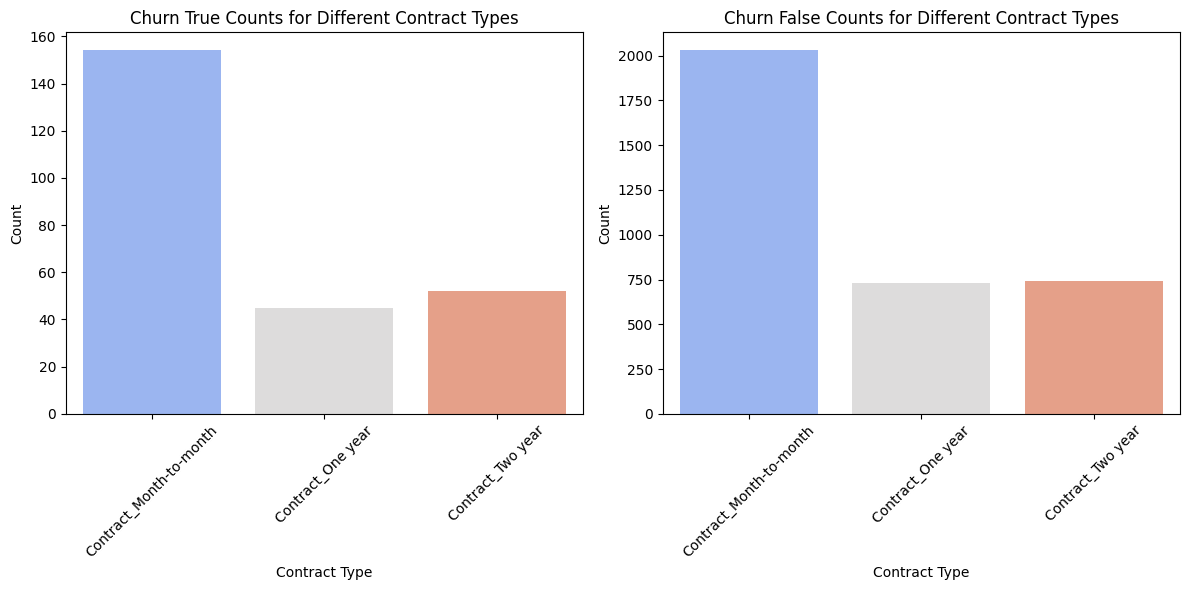

In [37]:
# Filter dataframe for churn True and churn False
df_churn_true = df[df['Churn'] == True]
df_churn_false = df[df['Churn'] == False]

# Calculate churn counts for each contract type for churn True and churn False
churn_true_counts = df_churn_true.filter(like='Contract').sum()
churn_false_counts = df_churn_false.filter(like='Contract').sum()

# Plot bar plots for churn True and churn False
plt.figure(figsize=(12, 6))

# Bar plot for churn True
plt.subplot(1, 2, 1)
sns.barplot(x=churn_true_counts.index, y=churn_true_counts.values, palette='coolwarm')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.title('Churn True Counts for Different Contract Types')
plt.xticks(rotation=45)

# Bar plot for churn False
plt.subplot(1, 2, 2)
sns.barplot(x=churn_false_counts.index, y=churn_false_counts.values, palette='coolwarm')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.title('Churn False Counts for Different Contract Types')
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

#### Monthly charges vs. Churn

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2591450100.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.MonthlyCharges[df["Churn"] == False], color="Red", shade=True)
/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2591450100.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.MonthlyCharges[df["Churn"] == True], ax=ax, color="Blue", shade=True)


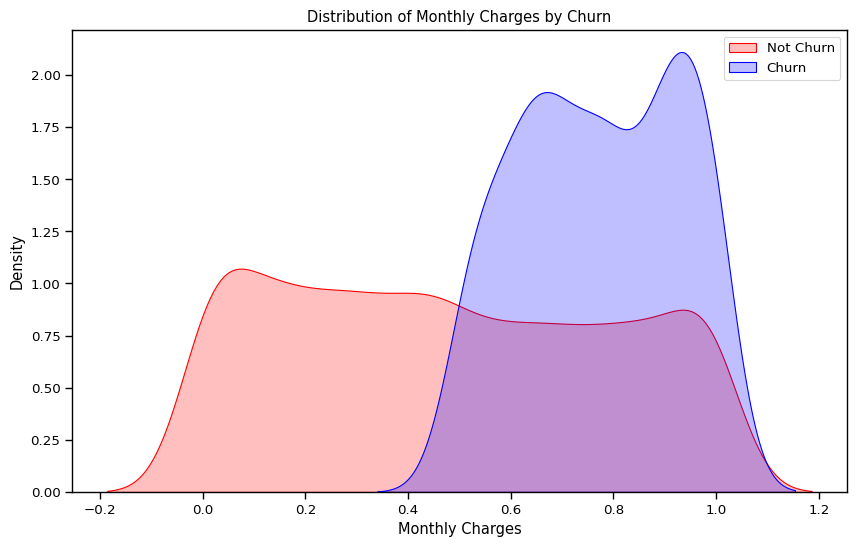

In [38]:
# Set the context and font scale
sns.set_context("paper", font_scale=1.1)

# Create KDE plot for Monthly Charges by churn status
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(df.MonthlyCharges[df["Churn"] == False], color="Red", shade=True)
ax = sns.kdeplot(df.MonthlyCharges[df["Churn"] == True], ax=ax, color="Blue", shade=True)

# Set labels and title
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Monthly Charges')
ax.set_title('Distribution of Monthly Charges by Churn')

plt.show()

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2087504722.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.TotalCharges[df["Churn"] == False], color="Red", shade=True)
/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2087504722.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.TotalCharges[df["Churn"] == True], ax=ax, color="Blue", shade=True)


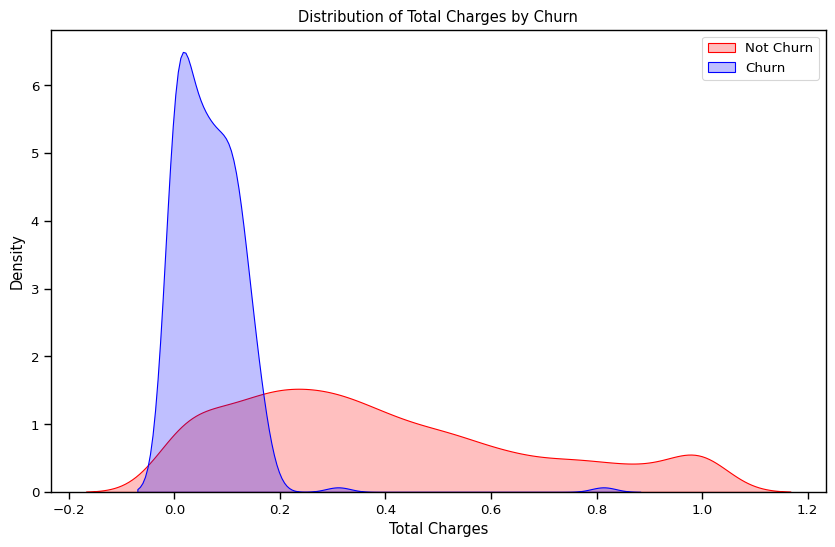

In [39]:
# Set the context and font scale
sns.set_context("paper", font_scale=1.1)

# Create KDE plot for Total Charges by churn status
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(df.TotalCharges[df["Churn"] == False], color="Red", shade=True)
ax = sns.kdeplot(df.TotalCharges[df["Churn"] == True], ax=ax, color="Blue", shade=True)

# Set labels and title
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Total Charges')
ax.set_title('Distribution of Total Charges by Churn')

plt.show()

#### this probably shows that customers with less tenure are more likely to churn. let's check it

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/3620583763.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.Tenure[df["Churn"] == False], color="Red", shade=True)
/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/3620583763.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.Tenure[df["Churn"] == True], ax=ax, color="Blue", shade=True)


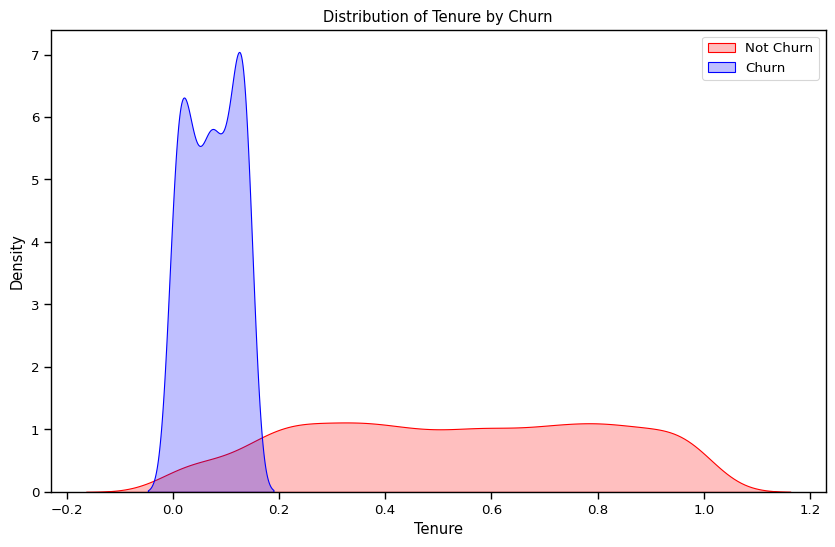

In [40]:
import seaborn as sns

# Set the context and font scale
sns.set_context("paper", font_scale=1.1)

# Create KDE plot for Tenure by churn status
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(df.Tenure[df["Churn"] == False], color="Red", shade=True)
ax = sns.kdeplot(df.Tenure[df["Churn"] == True], ax=ax, color="Blue", shade=True)

# Set labels and title
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Tenure')
ax.set_title('Distribution of Tenure by Churn')

plt.show()


/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/242897313.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.Age[df["Churn"] == False], color="Red", shade=True)
/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/242897313.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(df.Age[df["Churn"] == True], ax=ax, color="Blue", shade=True)


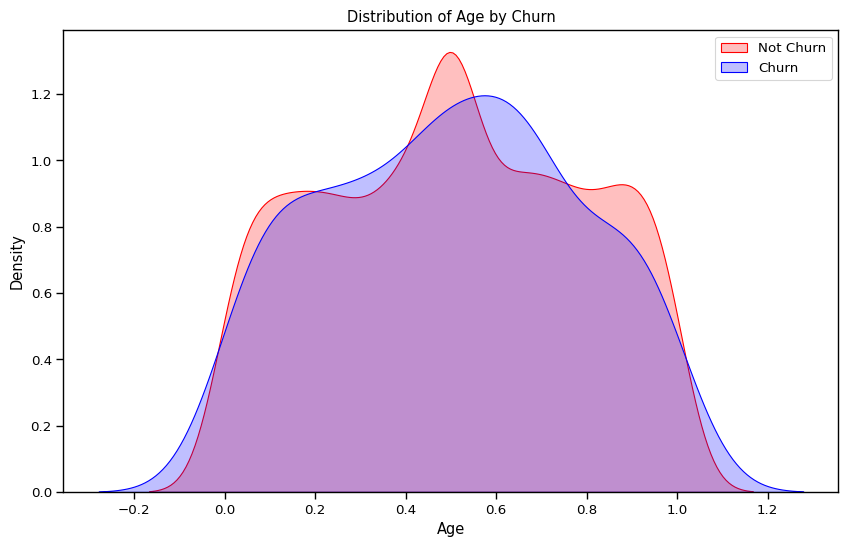

In [41]:
# Set the context and font scale
sns.set_context("paper", font_scale=1.1)

# Create KDE plot for Age by churn status
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(df.Age[df["Churn"] == False], color="Red", shade=True)
ax = sns.kdeplot(df.Age[df["Churn"] == True], ax=ax, color="Blue", shade=True)

# Set labels and title
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Age')
ax.set_title('Distribution of Age by Churn')

plt.show()

### 3.3. Hypothesis test

#### T-test for numerical values

In [42]:
import scipy.stats as stats

# Extract Monthly Charges for churned and non-churned customers
monthly_charges_churned = df[df['Churn'] == True]['MonthlyCharges']
monthly_charges_not_churned = df[df['Churn'] == False]['MonthlyCharges']

# Perform t-test for Monthly Charges
t_stat_monthly_charges, p_value_monthly_charges = stats.ttest_ind(monthly_charges_churned, monthly_charges_not_churned)
print("T-test results for Monthly Charges:")
print(f"T-statistic: {t_stat_monthly_charges}")
print(f"P-value: {p_value_monthly_charges}")

# Extract Tenure for churned and non-churned customers
tenure_churned = df[df['Churn'] == True]['Tenure']
tenure_not_churned = df[df['Churn'] == False]['Tenure']

# Perform t-test for Tenure
t_stat_tenure, p_value_tenure = stats.ttest_ind(tenure_churned, tenure_not_churned)
print("\nT-test results for Tenure:")
print(f"T-statistic: {t_stat_tenure}")
print(f"P-value: {p_value_tenure}")


T-test results for Monthly Charges:
T-statistic: 14.692131979840543
P-value: 1.4869710712448252e-47

T-test results for Tenure:
T-statistic: -26.15828421461127
P-value: 1.1181117085372203e-138


#### The analysis shows that the average values of both Monthly Charges and Tenure are significantly different between customers who left and those who stayed. The very low p-values (close to zero) strongly suggest that these differences are not due to chance, meaning that Monthly Charges and Tenure are truly associated with customer churn.

## 4. Feature engineering

In [43]:
# Convert 'yes'/'no' values to 1/0
df['Service_Phone'] = df['Service_Phone'].map({'Yes': 1, 'No': 0})
df['Service_TV'] = df['Service_TV'].map({'Yes': 1, 'No': 0})
df['StreamingMovies'] = df['StreamingMovies'].map({'Yes': 1, 'No': 0})
df['StreamingMusic'] = df['StreamingMusic'].map({'Yes': 1, 'No': 0})

# Create TotalServiceUsage by summing the binary columns
df['TotalServiceUsage'] = df['Service_Phone'] + df['Service_TV'] + df['StreamingMovies'] + df['StreamingMusic']

# Display the updated DataFrame
df[['Service_Phone', 'Service_TV', 'StreamingMovies', 'StreamingMusic', 'TotalServiceUsage']].head()

,Service_Phone,Service_TV,StreamingMovies,StreamingMusic,TotalServiceUsage
0,1,0,0,0,1
1,0,1,1,1,3
2,0,1,1,1,3
3,1,1,0,1,3
4,1,1,1,0,3


In [44]:
# Identify binary columns with True/False values
binary_columns = df.select_dtypes(include=['bool']).columns

# Convert True/False to 1/0
for column in binary_columns:
    df[column] = df[column].astype(int)

# Verify the conversion
df.head()

,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,MonthlyCharges,TotalCharges,StreamingMovies,...,TechSupport,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServiceUsage
0,08729464-bde6-43bc-8f63-a357096feab1,0.745098,Male,0.171429,DSL,1,0,0.513798,0.114698,0,...,0,0,0,1,0,0,0,0,1,1
1,af95bc95-baf4-4318-a21d-70d2ea3148b7,1.000000,Male,0.171429,DSL,0,1,0.946536,0.197752,1,...,0,0,0,0,1,0,0,0,1,3
2,1fe7eee6-2227-4400-9998-4d993f4a60fd,0.549020,Male,0.842857,Fiber optic,0,1,1.000000,1.000000,1,...,0,0,1,0,0,0,0,0,1,3
3,f736fe7b-1b44-4acd-84c2-21c4aef648be,0.274510,Female,0.800000,Fiber optic,1,1,0.583284,0.680307,0,...,1,0,1,0,0,1,0,0,0,3
4,4b40d12d-7633-4309-96b8-aee675ea20ae,0.823529,Male,0.728571,Fiber optic,1,1,0.054062,0.217235,1,...,1,0,0,0,1,0,0,1,0,3


In [45]:
# Mapping for contract durations
contract_length = {
    'Month-to-month': 1,
    'One year': 12,
    'Two year': 24
}

# Create the new column 'ContractLength' based on the existing contract columns
df['ContractLength'] = df[['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']].idxmax(axis=1)
df['ContractLength'] = df['ContractLength'].map({
    'Contract_Month-to-month': contract_length['Month-to-month'],
    'Contract_One year': contract_length['One year'],
    'Contract_Two year': contract_length['Two year']
})

# Drop the original contract columns
df.drop(columns=['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year'], inplace=True)

# Verify the changes
df[['ContractLength']].head()
df.head()

,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServiceUsage,ContractLength
0,08729464-bde6-43bc-8f63-a357096feab1,0.745098,Male,0.171429,DSL,1,0,0.513798,0.114698,0,0,1,0,0,0,0,0,1,1,12
1,af95bc95-baf4-4318-a21d-70d2ea3148b7,1.000000,Male,0.171429,DSL,0,1,0.946536,0.197752,1,1,0,0,0,0,0,0,1,3,24
2,1fe7eee6-2227-4400-9998-4d993f4a60fd,0.549020,Male,0.842857,Fiber optic,0,1,1.000000,1.000000,1,1,0,0,0,0,0,0,1,3,1
3,f736fe7b-1b44-4acd-84c2-21c4aef648be,0.274510,Female,0.800000,Fiber optic,1,1,0.583284,0.680307,0,1,0,1,0,1,0,0,0,3,1
4,4b40d12d-7633-4309-96b8-aee675ea20ae,0.823529,Male,0.728571,Fiber optic,1,1,0.054062,0.217235,1,0,1,1,0,0,0,1,0,3,24


In [46]:
# Drop the 'CustomerID' and 'Service_Internet' columns
df.drop(columns=['CustomerID'], inplace=True)
df.drop(columns=['Service_Internet'], inplace=True)
# Drop the 'Gender' column
df.drop(columns=['Gender'], inplace=True)

In [47]:
# Drop the service and payment method columns
df.drop(columns=['Service_Phone', 'Service_TV', 'StreamingMovies', 'StreamingMusic',
                 'PaymentMethod_Bank transfer', 'PaymentMethod_Credit card',
                 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'], inplace=True)

In [48]:
df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,OnlineSecurity,TechSupport,Churn,TotalServiceUsage,ContractLength
0,0.745098,0.171429,0.513798,0.114698,1,0,0,1,12
1,1.000000,0.171429,0.946536,0.197752,0,0,0,3,24
2,0.549020,0.842857,1.000000,1.000000,0,0,0,3,1
3,0.274510,0.800000,0.583284,0.680307,0,1,0,3,1
4,0.823529,0.728571,0.054062,0.217235,1,1,0,3,24


In [49]:
df.to_csv('processed_dataset.csv', index=False)


Feature Importance Scores:
Tenure               0.397045
MonthlyCharges       0.375834
TotalCharges         0.199356
Age                  0.013908
TotalServiceUsage    0.005856
ContractLength       0.003772
OnlineSecurity       0.002141
TechSupport          0.002087
dtype: float64


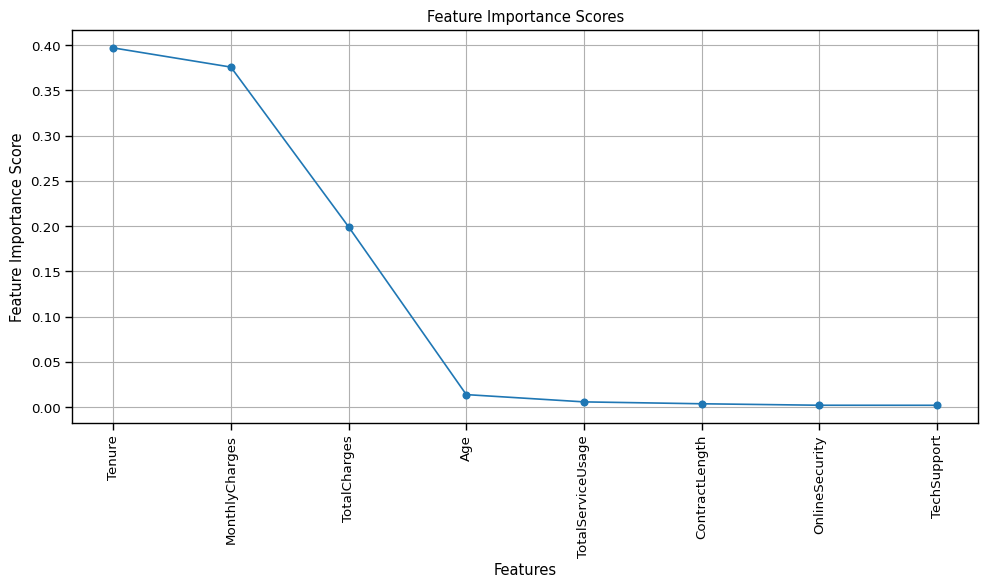

In [50]:
from sklearn.ensemble import RandomForestClassifier
# Feature Importance
# Prepare data for modeling
selected_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'OnlineSecurity', 'TechSupport', 'TotalServiceUsage', 'ContractLength']
X = df[selected_features]
y = df['Churn']

# Train Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance Scores:")
print(feature_importance)

# Plotting Feature Importance Scores with Lines
plt.figure(figsize=(10, 6))
plt.plot(feature_importance.values, marker='o', linestyle='-')
plt.xticks(np.arange(len(feature_importance)), feature_importance.index, rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature Importance Score')
plt.title('Feature Importance Scores')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Modeling 

### 5.1. Splitting the data into training and testing sets

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the processed dataset
df = pd.read_csv('processed_dataset.csv')

# Split the data into features (X) and the target variable (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (2999, 8) (2999,)
Testing set shape: (750, 8) (750,)


In [52]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [53]:
# Save training and testing sets as CSV files
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

### 5.2. Training models

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

LogisticRegression(max_iter=1000)
GradientBoostingClassifier(n_estimators=100)

# Initialize the models
models = [
    ('Logistic Regression', LogisticRegression(solver='liblinear', random_state=0, class_weight='balanced')),
    ('SVC', SVC(kernel='linear', random_state=0)),
    ('Kernel SVM', SVC(kernel='rbf', random_state=0)),
    ('KNN', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)),
    ('Decision Tree Classifier', DecisionTreeClassifier(criterion='entropy', random_state=0)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)),
    ('Adaboost', AdaBoostClassifier(algorithm='SAMME', random_state=42)),
    ('Gradient boost classifier', GradientBoostingClassifier()),
]

# Train and evaluate each model
results = {}
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    avg_cv_score = np.mean(cv_scores)
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc,
        'Cross-Validation Score': avg_cv_score
    }

# Print or store the results
for name, scores in results.items():
    print(f"{name} Metrics:")
    for metric, score in scores.items():
        print(f"{metric}: {score}")
    print()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression Metrics:
Accuracy: 0.948
Precision: 0.525
Recall: 0.9767441860465116
F1-score: 0.6829268292682927
ROC-AUC: 0.961497977040229
Cross-Validation Score: 0.9286449638286033

SVC Metrics:
Accuracy: 0.9786666666666667
Precision: 0.9090909090909091
Recall: 0.6976744186046512
F1-score: 0.7894736842105263
ROC-AUC: 0.8467155685668234
Cross-Validation Score: 0.9779938786867

Kernel SVM Metrics:
Accuracy: 0.9426666666666667
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5
Cross-Validation Score: 0.9306438508625489

KNN Metrics:
Accuracy: 0.9613333333333334
Precision: 0.8181818181818182
Recall: 0.4186046511627907
F1-score: 0.5538461538461539
ROC-AUC: 0.7064734712673926
Cross-Validation Score: 0.9496488592097941

Decision Tree Classifier Metrics:
Accuracy: 0.9986666666666667
Precision: 0.9772727272727273
Recall: 1.0
F1-score: 0.9885057471264368
ROC-AUC: 0.9992927864214992
Cross-Validation Score: 0.9989994435169727

Random Forest Metrics:
Accuracy: 0.9986666666666667
Precision

### 5.3. Model Evaluation

In [56]:
# Create a DataFrame from the results dictionary
results_df = pd.DataFrame(results).transpose()

# Display the DataFrame
display(results_df)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Cross-Validation Score
Logistic Regression,0.948000,0.525000,0.976744,0.682927,0.961498,0.928645
SVC,0.978667,0.909091,0.697674,0.789474,0.846716,0.977994
Kernel SVM,0.942667,0.000000,0.000000,0.000000,0.500000,0.930644
KNN,0.961333,0.818182,0.418605,0.553846,0.706473,0.949649
Decision Tree Classifier,0.998667,0.977273,1.000000,0.988506,0.999293,0.998999
Random Forest,0.998667,0.977273,1.000000,0.988506,0.999293,0.999333
Adaboost,0.998667,0.977273,1.000000,0.988506,0.999293,0.999666
Gradient boost classifier,0.998667,0.977273,1.000000,0.988506,0.999293,0.998999


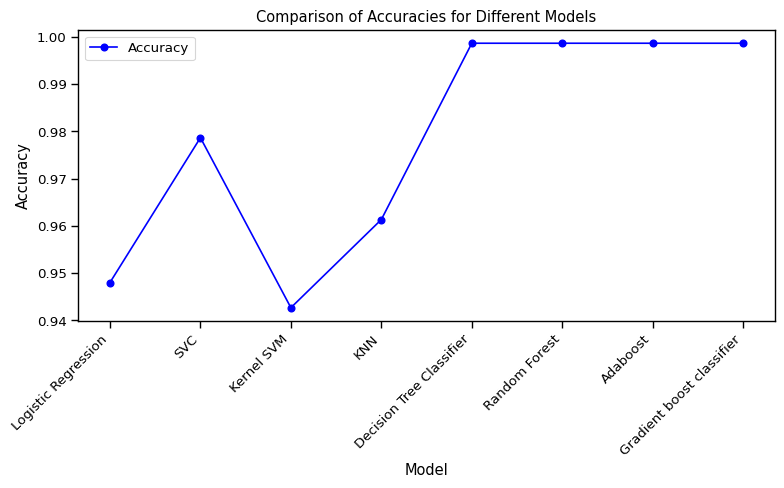

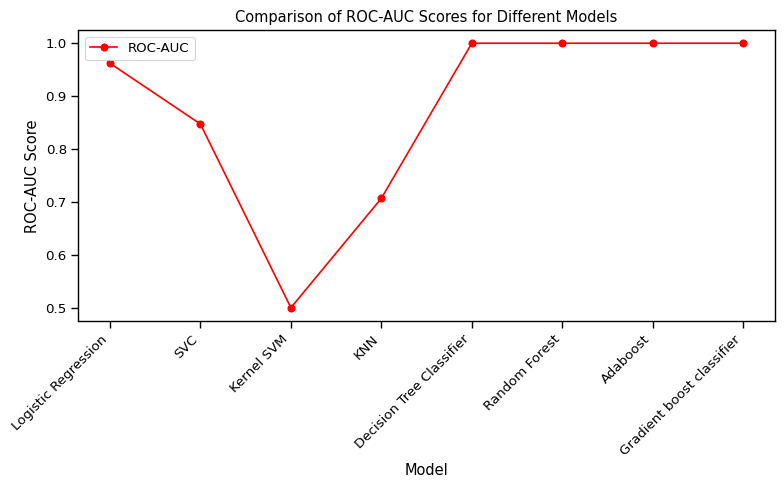

In [57]:
import matplotlib.pyplot as plt

# Extract metrics from the results dictionary
models = list(results.keys())
accuracies = [results[model]['Accuracy'] for model in models]
roc_auc_scores = [results[model]['ROC-AUC'] for model in models]

# Plot accuracies
plt.figure(figsize=(8, 5))
plt.plot(models, accuracies, marker='o', linestyle='-', color='b', label='Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracies for Different Models')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Plot ROC-AUC scores
plt.figure(figsize=(8, 5))
plt.plot(models, roc_auc_scores, marker='o', linestyle='-', color='r', label='ROC-AUC')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.title('Comparison of ROC-AUC Scores for Different Models')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4. Cross Validation

In [58]:
from sklearn.model_selection import cross_val_score

models = [
    ('Logistic Regression', LogisticRegression(solver='liblinear', random_state=0, class_weight='balanced')),
    ('SVC', SVC(kernel='linear', random_state=0)),
    ('Kernel SVM', SVC(kernel='rbf', random_state=0)),
    ('KNN', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)),
    ('Decision Tree Classifier', DecisionTreeClassifier(criterion='entropy', random_state=0)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)),
    ('Adaboost', AdaBoostClassifier(algorithm='SAMME', random_state=42)),
    ('Gradient boost classifier', GradientBoostingClassifier()),
]

# Create an empty DataFrame to store results
results_df = pd.DataFrame(columns=["Model", "Mean Accuracy", "Std Accuracy"])

# Perform cross-validation for each model
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=10)
    model_results = pd.DataFrame({
        "Model": [name],
        "Mean Accuracy": [scores.mean()],
        "Std Accuracy": [scores.std()]
    })
    results_df = pd.concat([results_df, model_results], ignore_index=True)

# Display the results
print(results_df)


/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_57319/2801043571.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, model_results], ignore_index=True)


                       Model  Mean Accuracy  Std Accuracy
0        Logistic Regression       0.927972      0.015311
1                        SVC       0.978327      0.007780
2                 Kernel SVM       0.930644      0.001290
3                        KNN       0.951314      0.008477
4   Decision Tree Classifier       0.999000      0.002134
5              Random Forest       0.999667      0.001000
6                   Adaboost       0.999667      0.001000
7  Gradient boost classifier       0.999000      0.002134


# 6. Model Tuning

### Hyperparameter tuning: GridSearchCV

In [59]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize the grid search with the classifier and hyperparameter grid
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')

# Perform grid search
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate the best model
best_model_score = best_model.score(X_test, y_test)

# Print the best hyperparameters and model score
print("Best Hyperparameters:", best_params)
print("Best Model Score:", best_model_score)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Model Score: 0.9986666666666667


In [60]:
from sklearn.model_selection import cross_val_score
from scipy import stats

# Default Model
default_model = DecisionTreeClassifier()
default_scores = cross_val_score(default_model, X_train, y_train, cv=5, scoring='accuracy')
default_mean = default_scores.mean()
print("Default Model Accuracy:", default_mean)

# Tuned Model
tuned_model = grid_search.best_estimator_
tuned_scores = cross_val_score(tuned_model, X_train, y_train, cv=5, scoring='accuracy')
tuned_mean = tuned_scores.mean()
print("Tuned Model Accuracy:", tuned_mean)

# Compare Performance
try:
    t_stat, p_value = stats.ttest_rel(default_scores, tuned_scores)
    print("T-Statistic:", t_stat)
    print("P-Value:", p_value)
    if not np.isnan(t_stat) and not np.isnan(p_value):
        if p_value < 0.05:
            print("Performance improvement is statistically significant.")
        else:
            print("No statistically significant difference in performance.")
    else:
        print("Unable to compute t-statistic and p-value due to no variation in scores.")
except Exception as e:
    print("An error occurred while computing t-statistic and p-value:", e)

Default Model Accuracy: 0.9989994435169727
Tuned Model Accuracy: 0.9989994435169727
T-Statistic: nan
P-Value: nan
Unable to compute t-statistic and p-value due to no variation in scores.


### Hyperparameter tuning was applied to the Decision Tree model using GridSearchCV, but the tuned model showed identical cross-validation accuracy to the default one (≈99.9%), indicating that the default tree was already highly optimized for this dataset.

# 7. Model Interpretation

### 7.1. Feature Importance Analysis

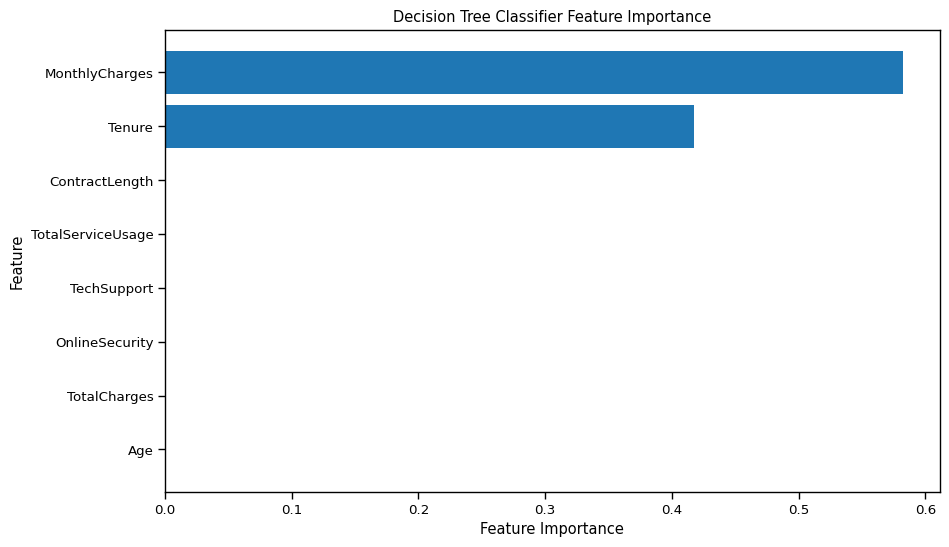

In [61]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Initialize and train the decision tree classifier
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train, y_train)

# Get feature importances
feature_importances = dt_classifier.feature_importances_

# Map feature importances to feature names
feature_names = X.columns

# Sort features by importance
sorted_indices = feature_importances.argsort()

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_indices)), feature_importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Classifier Feature Importance')
plt.show()


## 7.2 LIME 

In [62]:
import lime
import lime.lime_tabular
from sklearn.pipeline import make_pipeline
import numpy as np

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    mode='classification',
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn']  # это необязательно, но полезно
)

# Create pipeline with trained model
pipe = make_pipeline(dt_classifier)

# Select a random instance from the test set
instance_idx = np.random.randint(0, len(X_test))
instance = X_test.iloc[instance_idx]

# Explain model prediction using LIME
explanation = explainer.explain_instance(
    data_row=instance.values,
    predict_fn=pipe.predict_proba,
    num_features=len(X.columns)
)

# Save the explanation as HTML file
html_path = 'lime_explanation.html'
with open(html_path, 'w') as f:
    f.write(explanation.as_html())

print(f'LIME explanation saved to {html_path}')


LIME explanation saved to lime_explanation.html


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# 8. Final Model

### 8.1. Model prediction

In [63]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.9986666666666667
Precision: 0.9772727272727273
Recall: 1.0
F1-score: 0.9885057471264368
ROC-AUC score: 0.9992927864214992
Confusion Matrix:
[[706   1]
 [  0  43]]


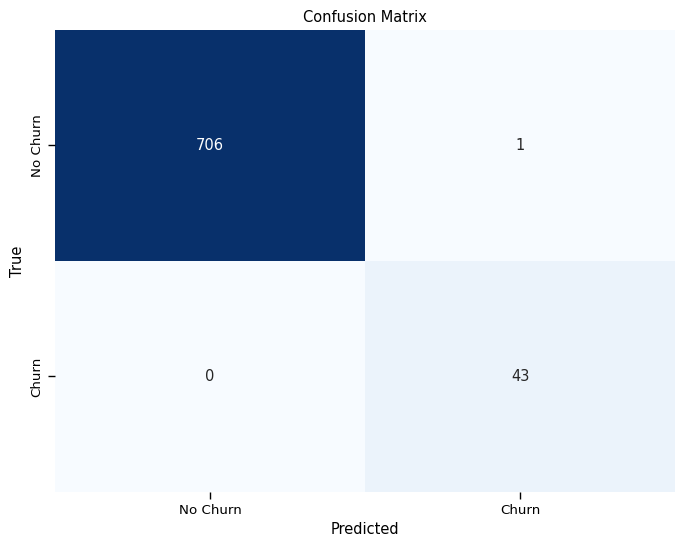

In [65]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### 8.2. Final Model

In [66]:
import joblib

# Save the model to a file
joblib.dump(model, 'final_model.pkl')

['final_model.pkl']

In [67]:
# Load the saved model from file
loaded_model = joblib.load('final_model.pkl')

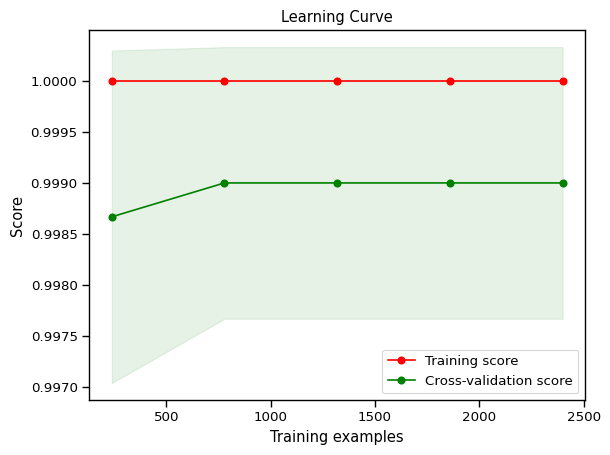

In [68]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import GradientBoostingClassifier

# Function to plot learning curves
def plot_learning_curve(estimator, X, y, cv, n_jobs):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, scoring='accuracy')
    
    train_scores_mean = train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    validation_scores_mean = validation_scores.mean(axis=1)
    validation_scores_std = validation_scores.std(axis=1)
    
    plt.figure()
    plt.title("Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                     validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best")
    plt.show()

# Plot learning curve for the Gradient Boosting Classifier using your training data
plot_learning_curve(GradientBoostingClassifier(), X_train, y_train, cv=5, n_jobs=-1)


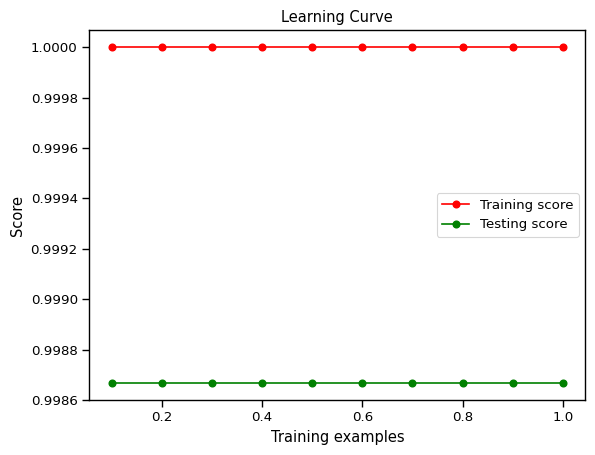

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the model
model = GradientBoostingClassifier()

# Define the training sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Lists to store scores
train_scores = []
test_scores = []

# Loop over the training sizes
for train_size in train_sizes:
    # Determine the number of training samples
    train_size = int(train_size * X_train.shape[0])
    
    # Train the model on the subset of the training set
    model.fit(X_train[:train_size], y_train[:train_size])
    
    # Evaluate the model on the training set
    y_train_pred = model.predict(X_train[:train_size])
    train_scores.append(accuracy_score(y_train[:train_size], y_train_pred))
    
    # Evaluate the model on the test set
    y_test_pred = model.predict(X_test)
    test_scores.append(accuracy_score(y_test, y_test_pred))

# Plot the learning curves
plt.figure()
plt.plot(train_sizes, train_scores, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores, 'o-', color="g", label="Testing score")
plt.title("Learning Curve")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()

In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-Validation Scores:", scores)
print("Mean CV Score:", scores.mean())

Cross-Validation Scores: [1.         0.99666667 1.         1.         0.99833055]
Mean CV Score: 0.9989994435169727
